## Imports

In [ ]:
from google.colab import drive
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
drive.mount('/content/drive')
output_dir = '/content/drive/MyDrive/final_FYP_results/test_preprocess'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [ ]:
# !pip install keras-tcn
!pip install keras-tcn --no-dependencies  # without the dependencies if you already have TF/Numpy.

In [ ]:
import random
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
# from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Layer

from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences

from nltk.corpus import stopwords

# import gensim
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings(action = 'ignore')

import shutil

import tensorflow_hub as hub
import tensorflow_text as text
# from official.nlp import optimization  # to create AdamW optimizer

tf.get_logger().setLevel('ERROR')

import kagglehub

import ast

import sklearn
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
import time

from tabulate import tabulate

import gc

def set_all_seeds(seed):
  """Sets the seed for all relevant random number generators."""
  os.environ['PYTHONHASHSEED'] = str(seed)
  random.seed(seed)
  np.random.seed(seed)
  tf.random.set_seed(seed)
  # tf.config.experimental.enable_op_determinism()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
FOLDS=5
seed_value = 42
set_all_seeds(seed_value)

In [ ]:
#Preprocessing function
def preprocessing_old(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # # Removing stopwords
    stop = stopwords.words('english')
    data_frame['Text'].apply(lambda x: [item for item in str(x) if item not in stop])

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    # Tokenizing Posts and counting the length of each post
    data_frame['Tokens'] = data_frame.apply(lambda row: word_tokenize(str(row['Text'])), axis=1)
    data_frame['Length'] = data_frame.apply(lambda row: len(row['Tokens']), axis=1)

    return data_frame

In [ ]:
def preprocessing_new_rm_dupNaN(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    # Drop NaN
    data_frame = data_frame.dropna(subset=['Text'])

    # Just show duplicate
    duplicates = data_frame[data_frame.duplicated(subset=['Text', 'Label'], keep=False)]
    duplicates = duplicates.sort_values(by=['Text', 'Label'])
    # Display result
    print("Duplicates:")
    print(duplicates)

    # Drop Dup
    data_frame = data_frame.drop_duplicates(subset=['Text','Label'])

    # Tokenizing Posts and counting the length of each post
    data_frame['Tokens'] = data_frame.apply(lambda row: word_tokenize(str(row['Text'])), axis=1)
    data_frame['Length'] = data_frame.apply(lambda row: len(row['Tokens']), axis=1)

    return data_frame

In [ ]:
def preprocessing_new(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    data_frame = data_frame.dropna(subset=['Text'])

    # Tokenize
    data_frame['Tokens'] = data_frame['Text'].apply(word_tokenize)

    # # Removing stopwords
    stop =  set(stopwords.words('english'))
    data_frame['Tokens'] = data_frame['Tokens'].apply(lambda tokens: [word for word in tokens if word not in stop])
    data_frame['Text'] = data_frame['Tokens'].apply(lambda tokens: ' '.join(tokens))

    # 10. Length of each token list
    data_frame['Length'] = data_frame['Tokens'].apply(len)

    data_frame = data_frame.dropna(subset=['Text'])

    # Just show duplicate
    duplicates = data_frame[data_frame.duplicated(subset=['Text', 'Label'], keep=False)]
    duplicates = duplicates.sort_values(by=['Text', 'Label'])
    # Display result
    print("Duplicates:")
    print(duplicates)

    data_frame = data_frame.drop_duplicates(subset=['Text','Label'])

    return data_frame

In [ ]:
def preprocessing_new_rm_stop_NaN(data_frame):
    ## Preprocessing
    # Removing URLs whithin the tweets
    data_frame["Text"] = data_frame["Text"].str.replace(r'\s*https?://\S+(\s+|$)', ' ', regex=True).str.strip()
    # Removing emails, hashtags and punctuations
    data_frame['Text'] = data_frame["Text"].str.replace(r'\S*@\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'#\S*\s?', ' ', regex=True).str.strip()
    data_frame['Text'] = data_frame['Text'].str.replace(r'[^\w\s]+', ' ', regex=True).str.strip()

    # Lowercase Text
    data_frame['Text'] = data_frame['Text'].str.lower()

    # Removing newline characters
    data_frame['Text'] = data_frame['Text'].str.rstrip()

    data_frame = data_frame.dropna(subset=['Text'])

    # Tokenize
    data_frame['Tokens'] = data_frame['Text'].apply(word_tokenize)

    # # Removing stopwords
    stop =  set(stopwords.words('english'))
    data_frame['Tokens'] = data_frame['Tokens'].apply(lambda tokens: [word for word in tokens if word not in stop])
    data_frame['Text'] = data_frame['Tokens'].apply(lambda tokens: ' '.join(tokens))

    # 10. Length of each token list
    data_frame['Length'] = data_frame['Tokens'].apply(len)

    data_frame = data_frame.dropna(subset=['Text'])

    return data_frame

In [ ]:
def extract_feature_bert(preprocessor, encoder, texts, seq_len=128, embedding_dim=512, batch_size=64):
    # Set layers to non-trainable for feature extraction
    encoder.trainable = False

    final_embeddings = np.zeros((len(texts), seq_len, embedding_dim), dtype=np.float32)
    print("\n Starting BERT feature extraction...")
    for i in range(0, len(texts), batch_size):
        batch_end = min(i + batch_size, len(texts))
        batch_texts = texts[i:batch_end]

        preprocessor_outputs = preprocessor(batch_texts.squeeze())
        encoder_outputs = encoder(preprocessor_outputs)

        sequence_embeddings = encoder_outputs["sequence_output"]

        final_embeddings[i:batch_end] = sequence_embeddings.numpy()
    print("Done")
    return final_embeddings

In [ ]:
def data_preparation(df):
  df['Tokens'] = df['Tokens'].apply(lambda x: ast.literal_eval[x] if isinstance(x, str) else x)

  texts = [' '.join(row) for row in df['Tokens']]

  texts = pd.DataFrame(texts)
  X = np.array(texts)
  y = df['Label'].to_numpy()
  return X, y

In [ ]:
def run_cross_validation(cv_splits, X, y, ModelClass, sequence_length=128, embedding_dim=512):
    batch_size = 64
    """
    Runs cross-validation for a given number of splits.

    Args:
        cv_splits (int): The number of folds for cross-validation (e.g., 5 or 10).

    Returns:
        pandas.DataFrame: A dataframe containing the results for each fold.
    """
    kfold = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    # Lists to store results for each fold
    accuracies, precisions, recalls, f1_scores, roc_auc_scores, training_times = [], [], [], [], [], []
    fold_no = 1

    for train_idx, test_idx in kfold.split(X, y):
        print(f"--- Starting Fold {fold_no}/{cv_splits} ---")

        # Split data for this fold
        X_train_first, X_test = X[train_idx], X[test_idx]
        y_train_first, y_test = y[train_idx], y[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_first,
            y_train_first,
            test_size=0.2,
            shuffle=True,
            stratify=y_train_first,
            random_state=42
        )


        train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
        val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

        # --- Model Creation and Compilation ---
        # Re-create the model inside the loop for a fresh start in each fold
        strategy = tf.distribute.MirroredStrategy()
        with strategy.scope():
            if ModelClass == tcn_model_fb_precompute:
                model = ModelClass(sequence_length=sequence_length, embedding_dim=embedding_dim, kernel_size=8, activation='relu')
            else:
                model = ModelClass(kernel_size=8, activation='relu')
            model.compile(loss='binary_crossentropy', optimizer='SGD', metrics=['accuracy'])
            model.summary()

        epochs = 30

        start_time = time.time()

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            batch_size=64,
            epochs=epochs,
            verbose=1
        )

        end_time = time.time()
        training_time = end_time - start_time
        training_times.append(training_time)

        # --- Evaluation ---
        test_dataset = tf.data.Dataset.from_tensor_slices((X_test)).batch(batch_size)
        pred_probs = model.predict(test_dataset)
        y_pred = (pred_probs > 0.5).astype(int)

        # Calculate metrics
        accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
        precision = sklearn.metrics.precision_score(y_test, y_pred)
        recall = sklearn.metrics.recall_score(y_test, y_pred)
        f1 = sklearn.metrics.f1_score(y_test, y_pred)
        roc_auc = sklearn.metrics.roc_auc_score(y_test, pred_probs)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        roc_auc_scores.append(roc_auc)

        print(f"Fold {fold_no} Results: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, ROC-AUC=={roc_auc:.4f}, Time={training_time:.2f}s")

        del model
        del history
        del train_dataset
        del val_dataset
        del test_dataset
        gc.collect()

        fold_no += 1

    # Create a DataFrame with the results
    results_df = pd.DataFrame({
        'Fold': list(range(1, cv_splits + 1)),
        'Accuracy': accuracies,
        'Precision': precisions,
        'Recall': recalls,
        'F1-Score': f1_scores,
        'ROC-AUC': roc_auc_scores,
        'Training Time (s)': training_times
    })

    return results_df

In [ ]:
def analyze_cv_results(results_df):
    """
    Analyzes and visualizes cross-validation results, consolidating
    plots for easier comparison.

    Args:
        results_df (pd.DataFrame): The DataFrame from run_cross_validation.
    """
    # --- Automatically get the variant name from the DataFrame ---
    if 'Variant' not in results_df.columns:
        print("Error: 'Variant' column not found in the DataFrame.")
        return
    variant_name = results_df['Variant'].iloc[0]
    print(f"--- Analysis for: {variant_name} - Reddit ---")
    print("-" * 50)

    # --- 1. Show the raw result ---
    print("\n[Raw Results per Fold]")
    # Use to_string() to ensure all rows/columns are printed
    print(results_df.drop(columns='Variant').to_string())

    # --- 2. Show the mean and standard deviation for each metric ---
    all_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Training Time (s)']
    summary_stats = results_df[all_metrics].agg(['mean', 'std']).T
    print("\n[Summary Statistics]")
    print(summary_stats)
    print("-" * 50)

    # --- 3. Show total training time ---
    total_time = results_df['Training Time (s)'].sum()
    print(f"\n[Total Training Time]: {total_time} seconds")

    # Define performance metrics for plotting (scale 0-1)
    performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

    # Reshape the data from wide to long format for easier plotting with Seaborn
    df_melted = results_df.melt(
        id_vars='Fold',
        value_vars=performance_metrics,
        var_name='Metric',
        value_name='Score'
    )

    # --- 3. Create a single plot with multiple box plots ---
    plt.style.use('seaborn-v0_8-whitegrid') # Use a modern seaborn style
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Metric', y='Score', data=df_melted, palette='pastel')
    plt.title(f'Metric Distribution for {variant_name} - Reddit', fontsize=16)
    plt.ylabel("Score")
    plt.xlabel("Metric Type")
    plt.show()
    print("")

    # --- 4. Create a single plot with multiple line plots ---
    plt.figure(figsize=(12, 7))
    sns.lineplot(x='Fold', y='Score', hue='Metric', data=df_melted, marker='o', palette='viridis')
    plt.title(f'Metric Performance Across Folds for {variant_name} - Reddit', fontsize=16)
    plt.ylabel("Score")
    plt.xlabel("Fold Number")
    plt.xticks(results_df['Fold'])
    plt.legend(loc='lower right')
    plt.show()
    print("")

    # --- Bar Chart for Training Time per Fold ---
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Fold', y='Training Time (s)', data=results_df, palette='rocket')
    for container in ax.containers:
      ax.bar_label(container, fmt='%.2f')
    plt.title(f'Training Time per Fold for {variant_name} - Reddit (seconds)', fontsize=16)
    plt.ylabel("Training Time (seconds)")
    plt.xlabel("Fold Number")
    plt.xticks(results_df['Fold'])
    plt.grid(axis='y', linestyle='--')
    plt.show()
    print("")

    del variant_name
    del all_metrics
    del summary_stats
    del total_time
    del df_melted
    gc.collect()

## BERT Model

In [ ]:
bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')
# bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'
# BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
# Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [ ]:
# Download selected bert version
preprocessor_path = kagglehub.model_download("tensorflow/bert/tensorFlow2/en-uncased-preprocess")
print("preprocessor_path to model files:", preprocessor_path)
bert_path = kagglehub.model_download("tensorflow/bert/tensorFlow2/bert-en-uncased-l-4-h-512-a-8/1")
print("preprocessor_path to model files:", bert_path)


100%|██████████| 4.55k/4.55k [00:00<00:00, 9.05MB/s]



100%|██████████| 276/276 [00:00<00:00, 410kB/s]



  0%|          | 0.00/1.74M [00:00<?, ?B/s]



100%|██████████| 1.75k/1.75k [00:00<00:00, 1.48MB/s]



  0%|          | 0.00/226k [00:00<?, ?B/s]


100%|██████████| 226k/226k [00:00<00:00, 1.05MB/s]

100%|██████████| 1.74M/1.74M [00:00<00:00, 4.70MB/s]


preprocessor_path to model files: /root/.cache/kagglehub/models/tensorflow/bert/tensorFlow2/en-uncased-preprocess/3



100%|██████████| 1.59k/1.59k [00:00<00:00, 2.18MB/s]



  0%|          | 0.00/111M [00:00<?, ?B/s]



  0%|          | 0.00/226k [00:00<?, ?B/s]




  0%|          | 0.00/4.44M [00:00<?, ?B/s]

100%|██████████| 226k/226k [00:00<00:00, 1.17MB/s]



 23%|██▎       | 1.00M/4.44M [00:00<00:01, 2.99MB/s]
  1%|          | 1.00M/111M [00:00<00:41, 2.76MB/s]


100%|██████████| 4.44M/4.44M [00:00<00:00, 9.77MB/s]

  3%|▎         | 3.00M/111M [00:00<00:15, 7.39MB/s]
  7%|▋         | 8.00M/111M [00:00<00:05, 19.4MB/s]
 13%|█▎        | 14.0M/111M [00:00<00:03, 30.6MB/s]
 16%|█▌        | 18.0M/111M [00:00<00:03, 31.2MB/s]
 23%|██▎       | 26.0M/111M [00:00<00:02, 41.9MB/s]
 30%|██▉       | 33.0M/111M [00:01<00:01, 47.1MB/s]
 34%|███▍      | 38.0M/111M [00:01<00:01, 41.5MB/s]
 39%|███▉      | 43.0M/111M [00:01<00:01, 40.1MB/s]
 43%|████▎     | 48.0M/111M [00:01<00:01, 39.8MB/s]
 49%|████▊     | 54.0M/111M [00:01<00:01, 43.2MB/s]
 56%|█████▌    | 62.0M/111M [00:01<00:01, 49.5MB/s]
 62%|██████▏   | 69.0M/111M [00:01<00:00, 52.3MB/s]
 69%|██████▊   | 76.0M/111M [00:02<00:00, 54.3MB/s]
 74%|███████▍  | 82.0M/111M [00:02<00:00, 51.8MB/s]
 78%|████

preprocessor_path to model files: /root/.cache/kagglehub/models/tensorflow/bert/tensorFlow2/bert-en-uncased-l-4-h-512-a-8/1


## Model

In [ ]:
# a custome Attention layer
class CustAttention(Layer):
  def __init__ (self, return_sequences=True):
    self.return_sequences = return_sequences
    super(CustAttention, self).__init__()

  def build (self, input_shape):
    self.W = self.add_weight(name="att_weight", shape=(input_shape[-1],1), initializer="normal")
    self.b = self.add_weight(name="att_bias", shape=(input_shape[1],1), initializer="zeros")
    super(CustAttention, self).build(input_shape)

  def call(self, x):
    e = K.tanh(K.dot(x, self.W)+self.b)
    a = K.softmax(e, axis=1)
    output = x*a
    if self.return_sequences:
      return output
    return K.sum(output, axis = 1)

# a custome Attention layer
class AttentionForSeqOut(Layer):
  def __init__ (self, return_sequences=True):
    self.return_sequences = return_sequences
    super(AttentionForSeqOut, self).__init__()

  def build (self, input_shape):
    self.W = self.add_weight(name="att_weight", shape=(input_shape[-1],1), initializer="normal")
    self.b = self.add_weight(name="att_bias", shape=(128,1), initializer="zeros")
    super(AttentionForSeqOut, self).build(input_shape)

  def call(self, x):
    e = K.tanh(K.dot(x, self.W)+self.b)
    a = K.softmax(e, axis=1)
    output = x*a
    if self.return_sequences:
      return output
    return K.sum(output, axis = 1)


In [ ]:
!pip install tensorflow_text
import tensorflow_text as text

In [ ]:
from tcn import TCN, tcn_full_summary
from keras.layers import Bidirectional
from tensorflow.keras.initializers import RandomNormal, Constant

from tensorflow.keras.layers import Bidirectional, Dense, Input, Embedding, Conv1D, GlobalMaxPooling1D, Dropout, LSTM
from tensorflow.compat.v1.keras.layers import CuDNNLSTM
from tensorflow.keras import regularizers
from tensorflow.keras.models import *

def tcn_model(kernel_size = 3, activation='relu'):

    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['pooled_output']

    x = tf.expand_dims(net, axis=1)  # Add a dummy dimension for timesteps

    x = SpatialDropout1D(0.1)(x)
    # x = LSTM(100, stateful=False, return_sequences = True)(x)
    x = CuDNNLSTM(100, stateful=False, return_sequences = True)(x)

    x = Bidirectional(TCN(128,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn1'))(x)
    x = Bidirectional(TCN(64,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn2'))(x)
    x = CustAttention(return_sequences=True)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    conc = concatenate([avg_pool, max_pool])
    conc = Dense(16, activation="relu")(conc)
    conc = Dropout(0.1)(conc)

    output = Dense(1, activation="sigmoid")(conc)
    # output = Dense(2, activation="softmax")(conc)

    model = Model(inputs=text_input, outputs=output)
    return model


def tcn_model_fb(kernel_size = 3, activation='relu'):

    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = outputs['sequence_output']

    x = SpatialDropout1D(0.1)(net)
    # x = LSTM(100, stateful=False, return_sequences = True)(x)
    x = CuDNNLSTM(100, stateful=False, return_sequences = True)(x)

    x = Bidirectional(TCN(128,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn1'))(x)
    x = Bidirectional(TCN(64,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn2'))(x)
    x = AttentionForSeqOut(return_sequences=True)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    conc = concatenate([avg_pool, max_pool])
    conc = Dense(16, activation="relu")(conc)
    conc = Dropout(0.1)(conc)

    output = Dense(1, activation="sigmoid")(conc)
    # output = Dense(2, activation="softmax")(conc)

    model = Model(inputs=text_input, outputs=output)
    return model

def tcn_model_fb_precompute(sequence_length=128, embedding_dim=512, kernel_size = 3, activation='relu'):

    embedding_input = Input(shape=(sequence_length, embedding_dim), dtype='float32', name='embedding_input')

    x = SpatialDropout1D(0.1)(embedding_input)
    # x = LSTM(100, stateful=False, return_sequences = True)(x)
    x = CuDNNLSTM(100, stateful=False, return_sequences = True)(x)

    x = Bidirectional(TCN(128,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn1'))(x)
    x = Bidirectional(TCN(64,dilations = [1, 2, 4], return_sequences=True, activation = activation, name = 'tcn2'))(x)
    x = CustAttention(return_sequences=True)(x)

    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)

    conc = concatenate([avg_pool, max_pool])
    conc = Dense(16, activation="relu")(conc)
    conc = Dropout(0.1)(conc)

    output = Dense(1, activation="sigmoid")(conc)
    # output = Dense(2, activation="softmax")(conc)

    model = Model(inputs=embedding_input, outputs=output)
    return model

In [ ]:
all_results = []

In [ ]:
## Use BERT as feature extraction
print("Loading TF-Hub models...")
preprocessor = hub.load(tfhub_handle_preprocess)
encoder = hub.load(tfhub_handle_encoder)
print("Models loaded.")

Loading TF-Hub models...
Models loaded.


In [ ]:
# Old Preprocess Reddit
Reddit_path = "/content/suicidal_ideation_reddit_annotated.csv"
df_reddit = pd.read_csv(Reddit_path, encoding='latin-1')
df_reddit = df_reddit.rename(columns={'usertext': 'Text', 'label': 'Label'})
df_reddit = preprocessing_old(df_reddit)
print(df_reddit)

print(list(df_reddit['Label']).count(1), list(df_reddit['Label']).count(0))

X, y = data_preparation(df_reddit)
print(X)

del df_reddit
gc.collect()

                                                    Text  Label  \
0      i just want to end my life so badly  my life i...      1   
1      my relationship is complicated and painful  bu...      1   
2      i owe a lot of money   so i have to work the c...      1   
3      on the 2 of october i overdosed i just felt so...      1   
4      everyone tells me how wonderful i am  but not ...      1   
...                                                  ...    ...   
12651  levar burton reads podcast made me realize how...      0   
12652  irony of fahrenheit 451 being turned into a mo...      0   
12653  has anyone else ever read ben bova s grand tou...      0   
12654  i ve set the date  only a little while longer ...      0   
12655  just wasted  10 000  my professor was going to...      0   

                                                  Tokens  Length  
0      [i, just, want, to, end, my, life, so, badly, ...      76  
1      [my, relationship, is, complicated, and, painf...     

20

--- Starting Fold 1/5 ---
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                    

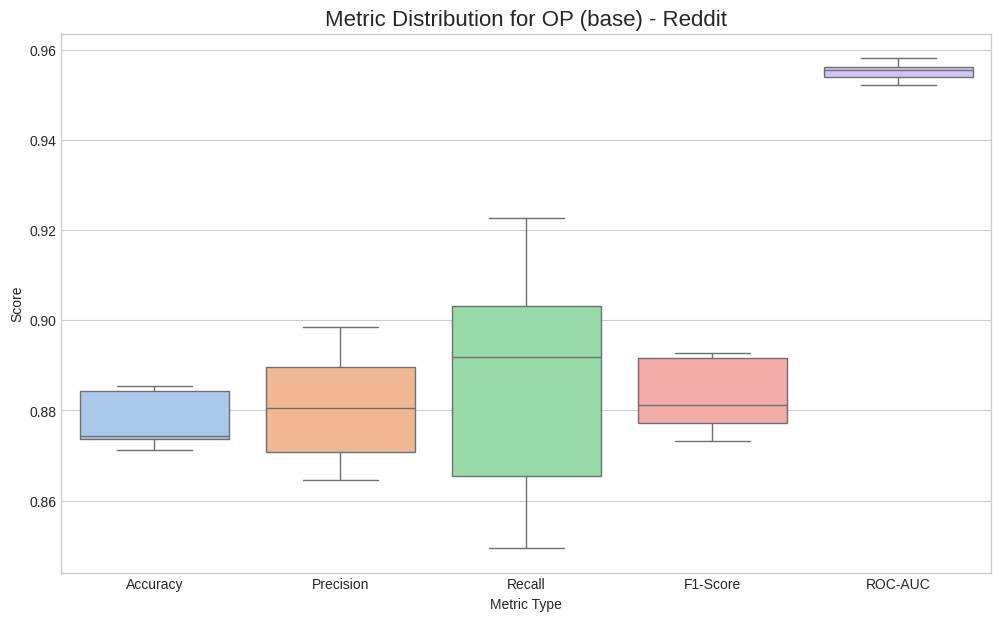

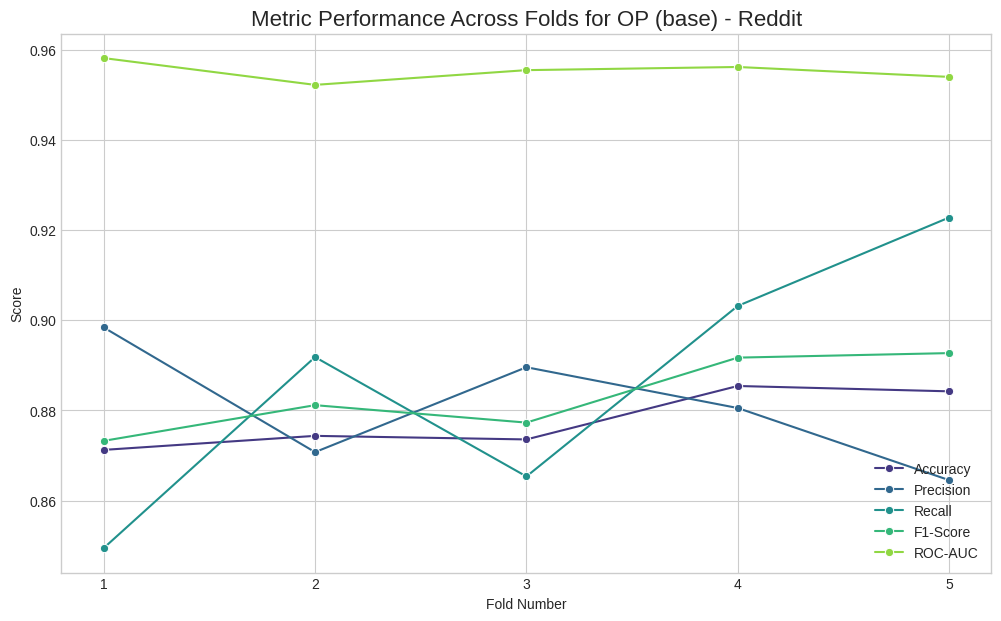

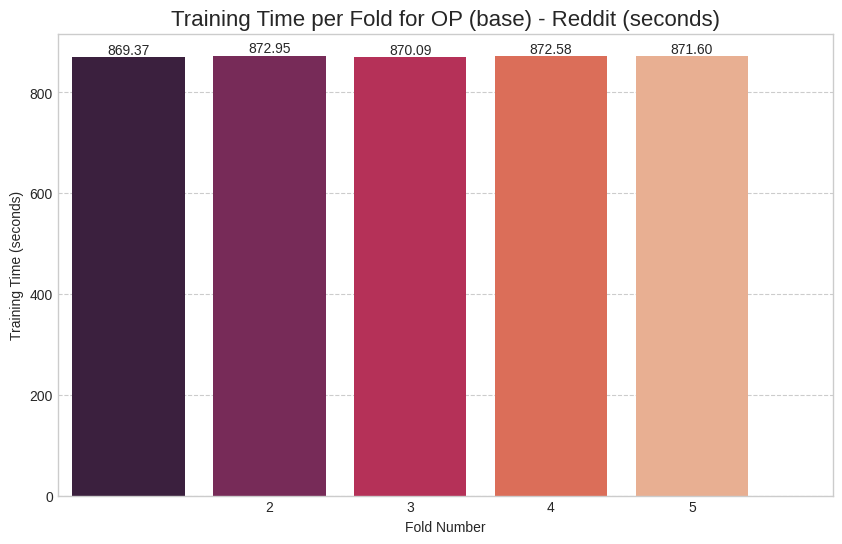

3119

In [ ]:
oldp_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model)
oldp_reddit_result['Variant'] = 'OP (base)'
oldp_reddit_result['Dataset'] = 'Reddit'
all_results.append(oldp_reddit_result)
analyze_cv_results(oldp_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/oldp_reddit_result.csv'
oldp_reddit_result.to_csv(output_filename, index=False)

del output_filename
del oldp_reddit_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                  

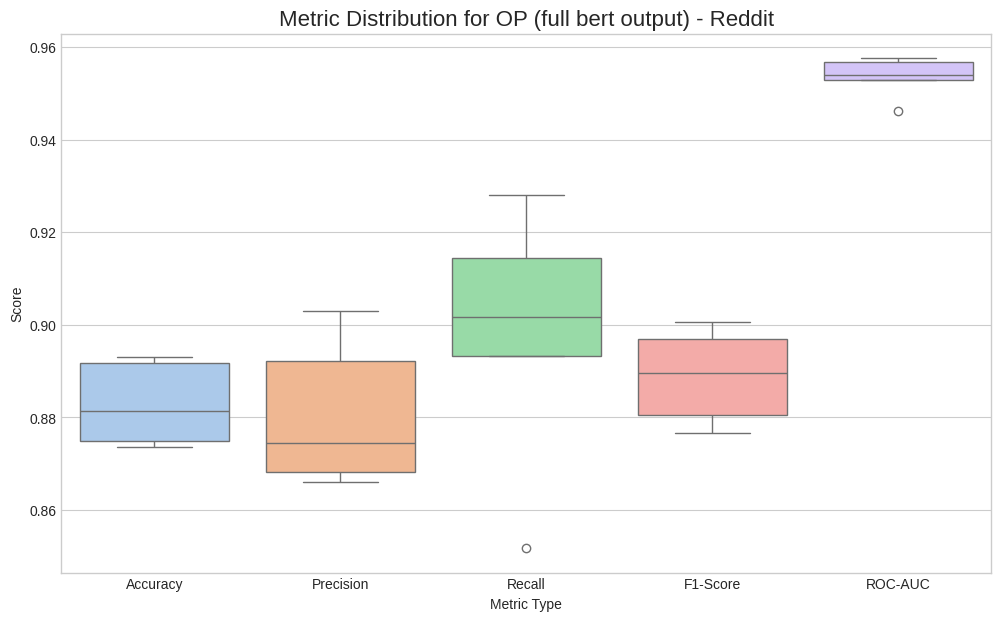

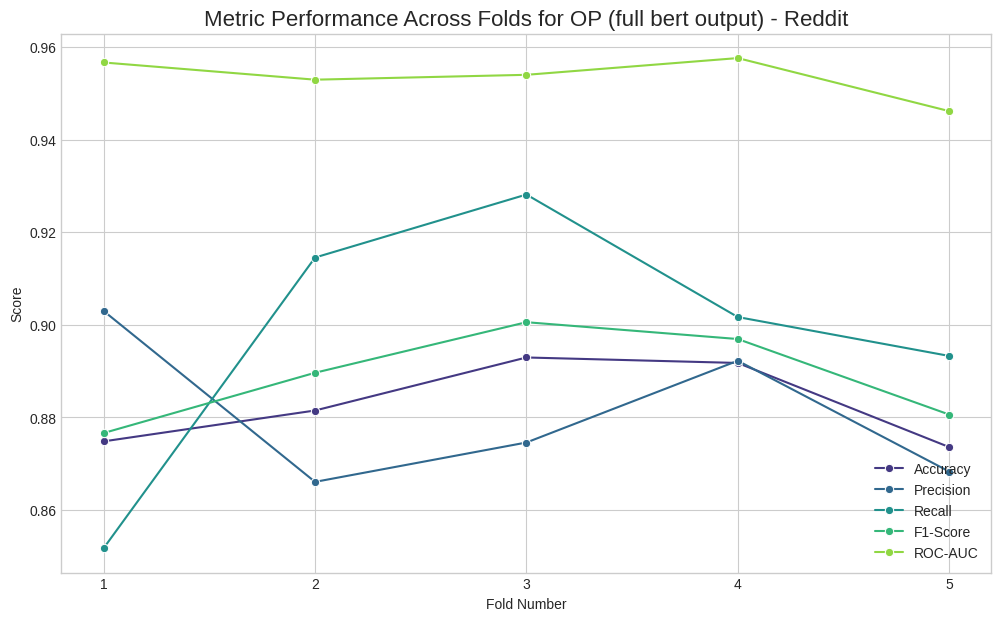

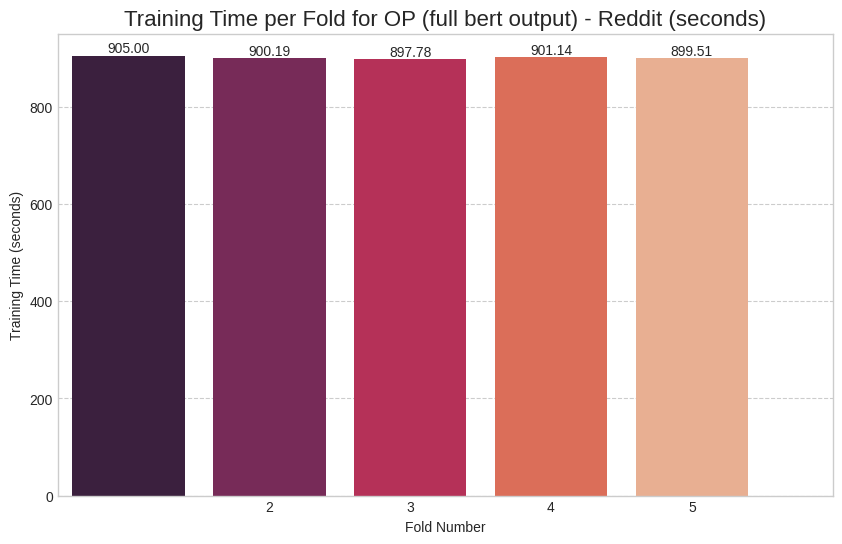

8126

In [ ]:
oldp_fb_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
oldp_fb_reddit_result['Variant'] = 'OP (full bert output)'
oldp_fb_reddit_result['Dataset'] = 'Reddit'
all_results.append(oldp_fb_reddit_result)
analyze_cv_results(oldp_fb_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/oldp_fb_reddit_result.csv'
oldp_fb_reddit_result.to_csv(output_filename, index=False)

del output_filename
del oldp_fb_reddit_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (12656, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_10 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_10 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout

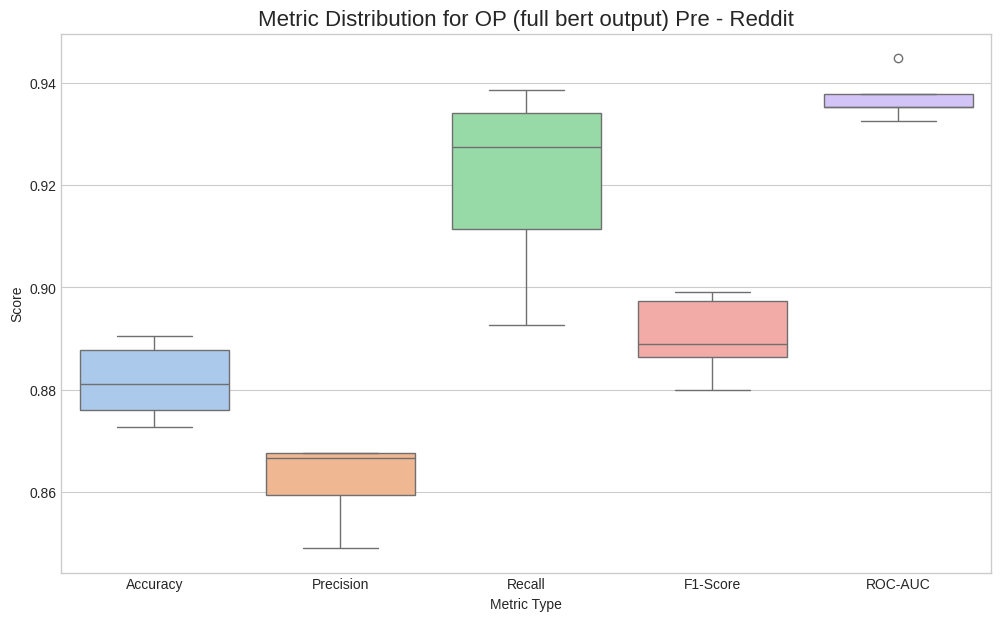

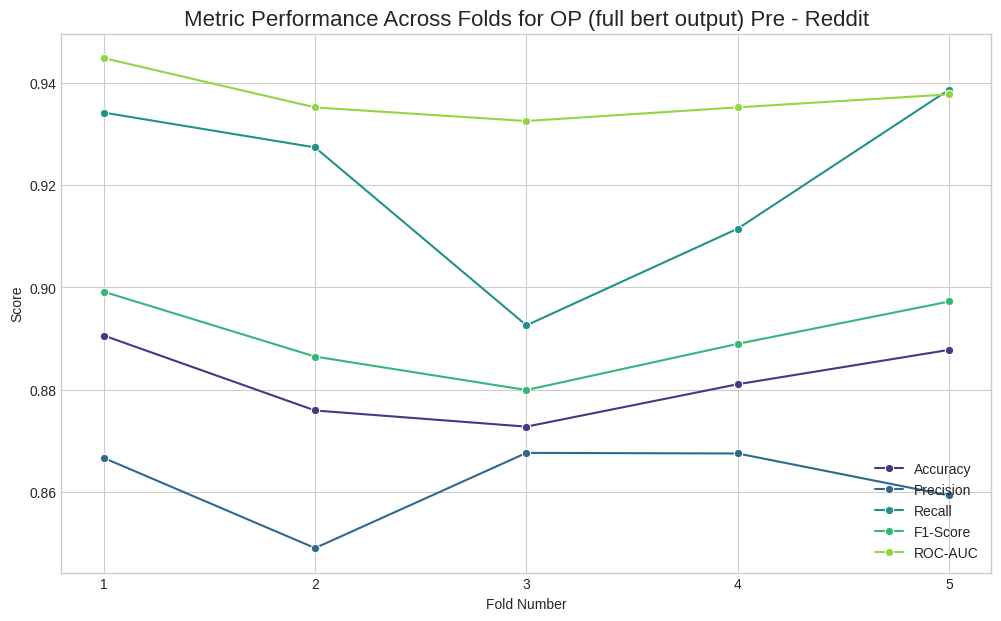

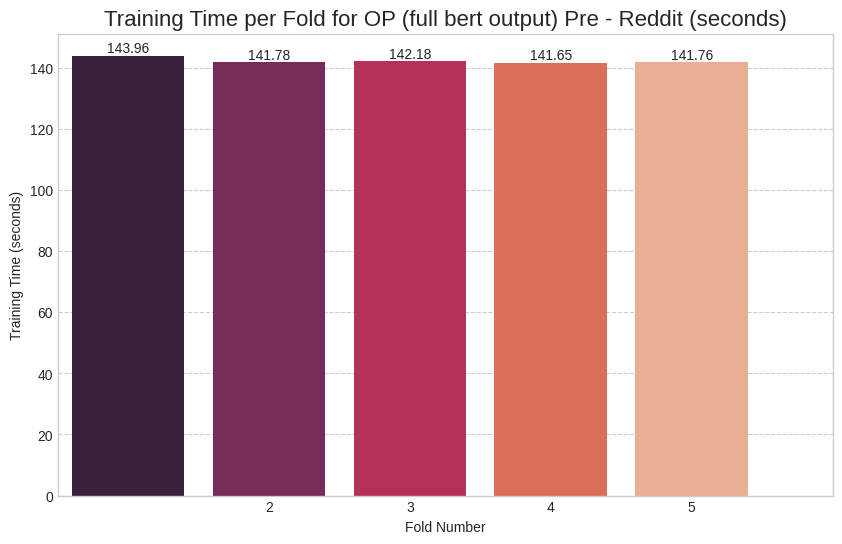

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

oldp_fb_pre_reddit_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
oldp_fb_pre_reddit_result['Variant'] = 'OP (full bert output) Pre'
oldp_fb_pre_reddit_result['Dataset'] = 'Reddit'
all_results.append(oldp_fb_pre_reddit_result)
analyze_cv_results(oldp_fb_pre_reddit_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/oldp_fb_pre_reddit_result.csv'
oldp_fb_pre_reddit_result.to_csv(output_filename, index=False)

del output_filename
del oldp_fb_pre_reddit_result
del X
del y
gc.collect()

In [ ]:
# New_rm_DN Preprocess Reddit
Reddit_path = "/content/suicidal_ideation_reddit_annotated.csv"
df_reddit = pd.read_csv(Reddit_path, encoding='latin-1')
df_reddit = df_reddit.rename(columns={'usertext': 'Text', 'label': 'Label'})
df_reddit = preprocessing_new_rm_dupNaN(df_reddit)
print(df_reddit)

print(list(df_reddit['Label']).count(1), list(df_reddit['Label']).count(0))

X, y = data_preparation(df_reddit)
print(X)

del df_reddit
gc.collect()

Duplicates:
                                                   Text  Label
986                                                          1
1050                                                         1
2113                                                         1
5097  about ready to throw it in  i m a young adult ...      1
6433  about ready to throw it in  i m a young adult ...      1
...                                                 ...    ...
3104                                                why      1
4829  why is suicide gonna be so hard  got people to...      1
6331  why is suicide gonna be so hard  got people to...      1
5240  worried about my brother  my brother has been ...      1
6483  worried about my brother  my brother has been ...      1

[103 rows x 2 columns]
                                                    Text  Label  \
0      i just want to end my life so badly  my life i...      1   
1      my relationship is complicated and painful  bu...      1   
2      

0

--- Starting Fold 1/5 ---
Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

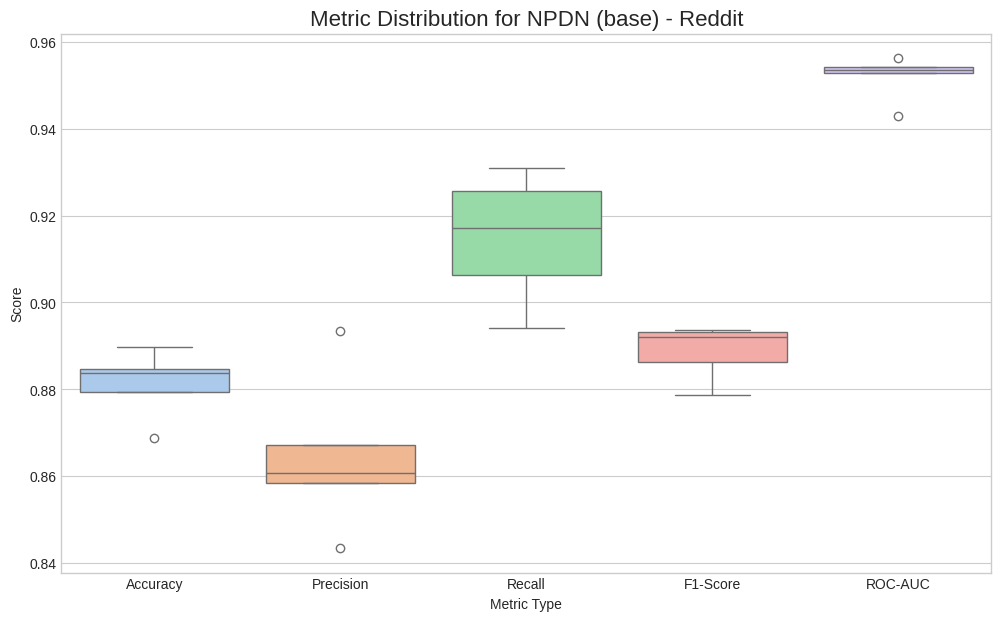

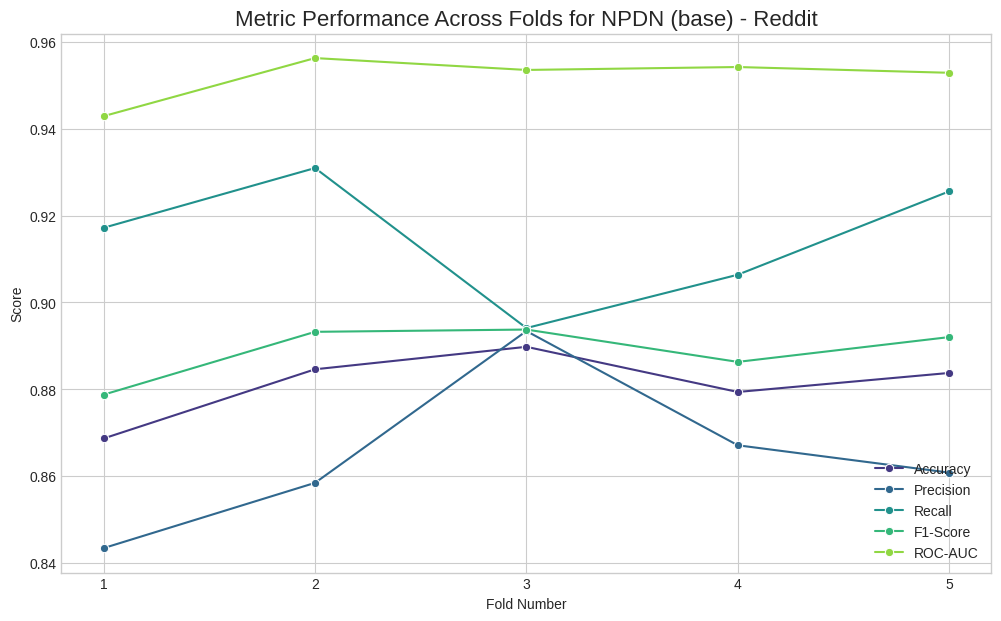

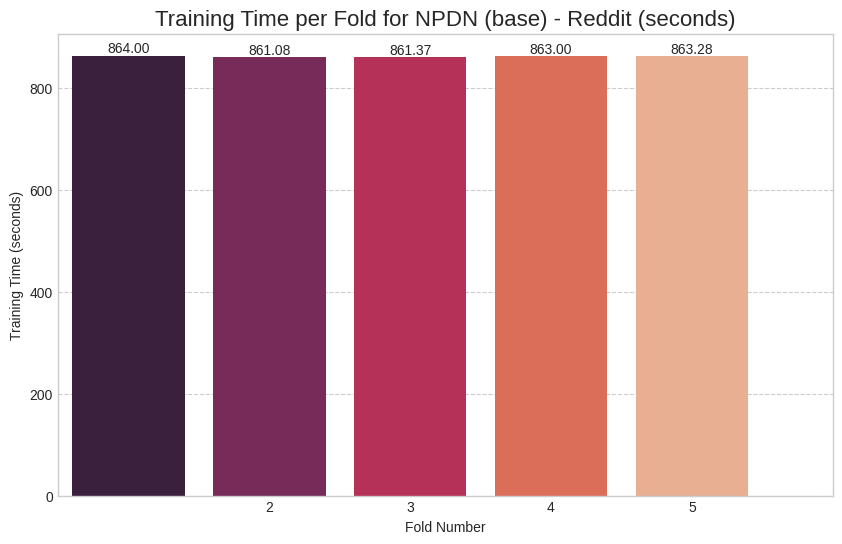

8223

In [ ]:
newdn_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model)
newdn_reddit_result['Variant'] = 'NPDN (base)'
newdn_reddit_result['Dataset'] = 'Reddit'
all_results.append(newdn_reddit_result)
analyze_cv_results(newdn_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newdn_reddit_result.csv'
newdn_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newdn_reddit_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_20"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

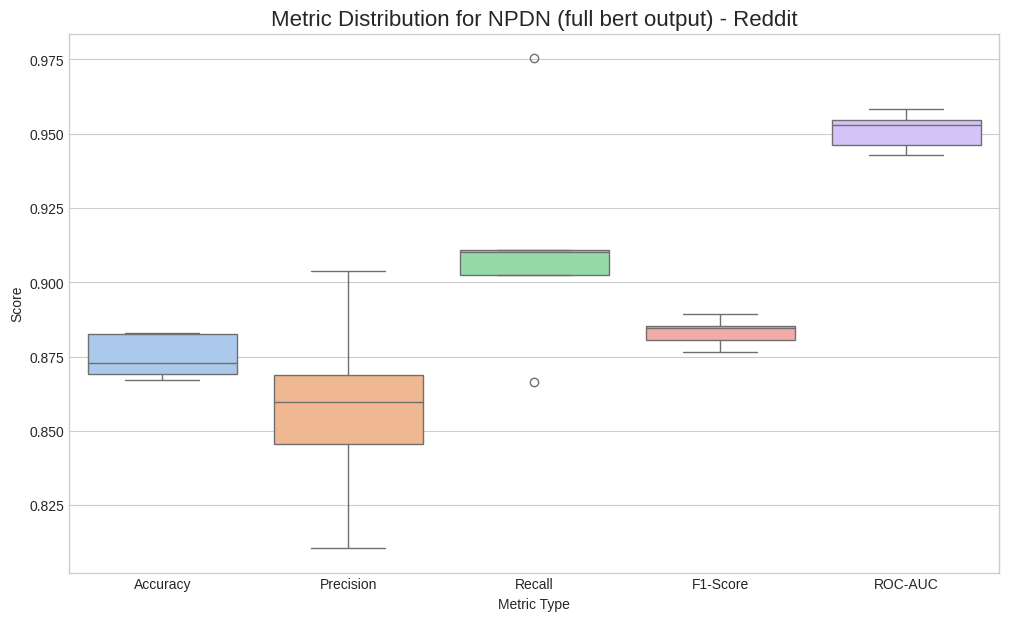

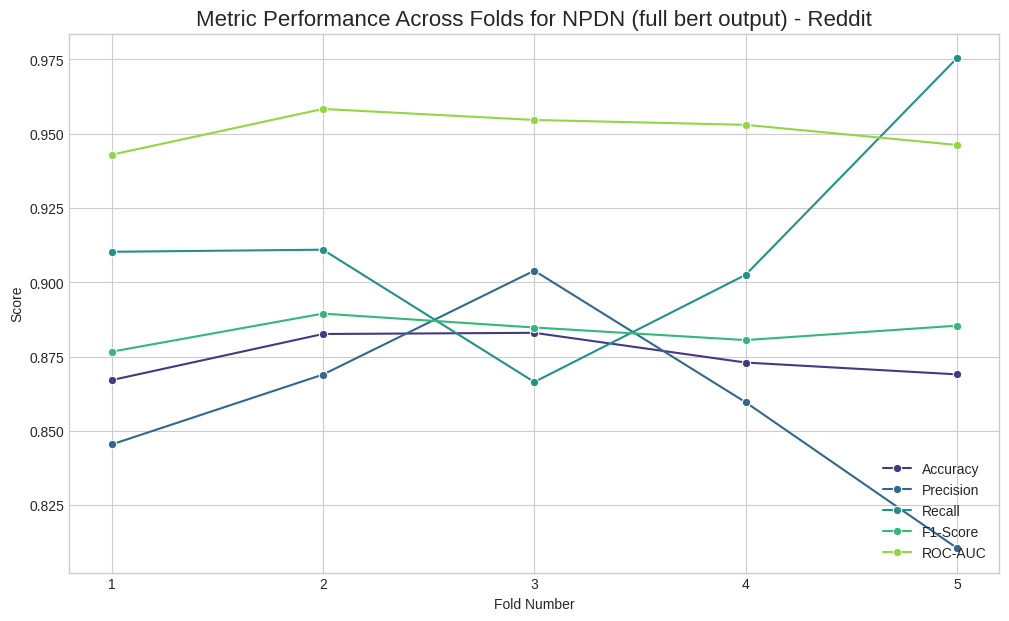

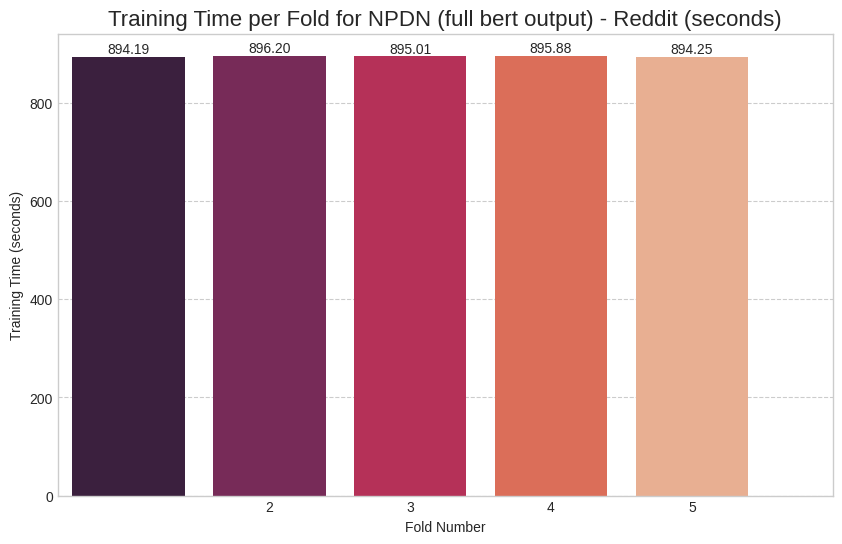

8223

In [ ]:
newdn_fb_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
newdn_fb_reddit_result['Variant'] = 'NPDN (full bert output)'
newdn_fb_reddit_result['Dataset'] = 'Reddit'
all_results.append(newdn_fb_reddit_result)
analyze_cv_results(newdn_fb_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newdn_fb_reddit_result.csv'
newdn_fb_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newdn_fb_reddit_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (12563, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_25"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_25 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_25 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout

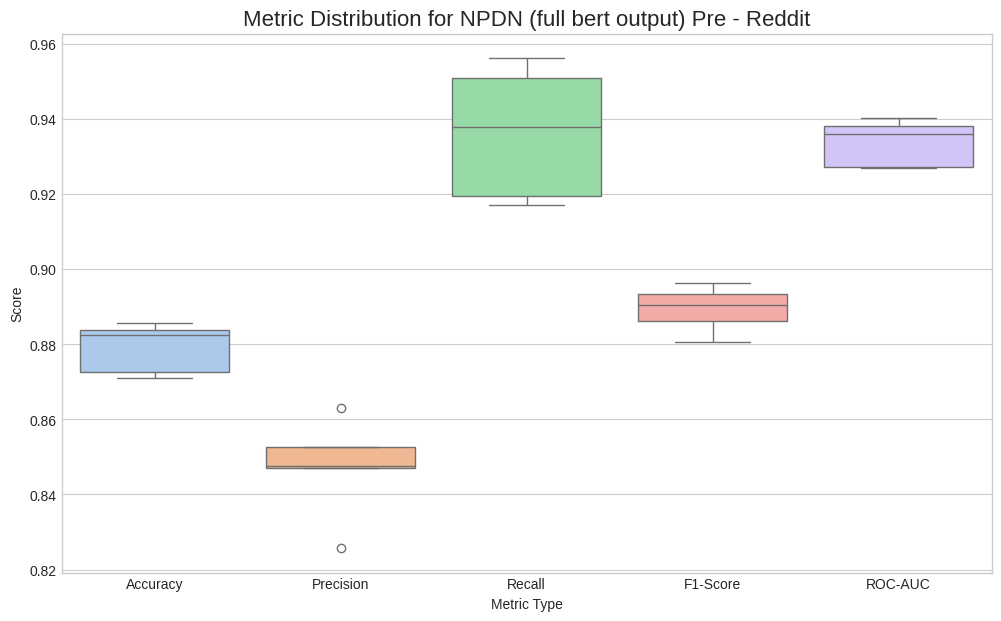

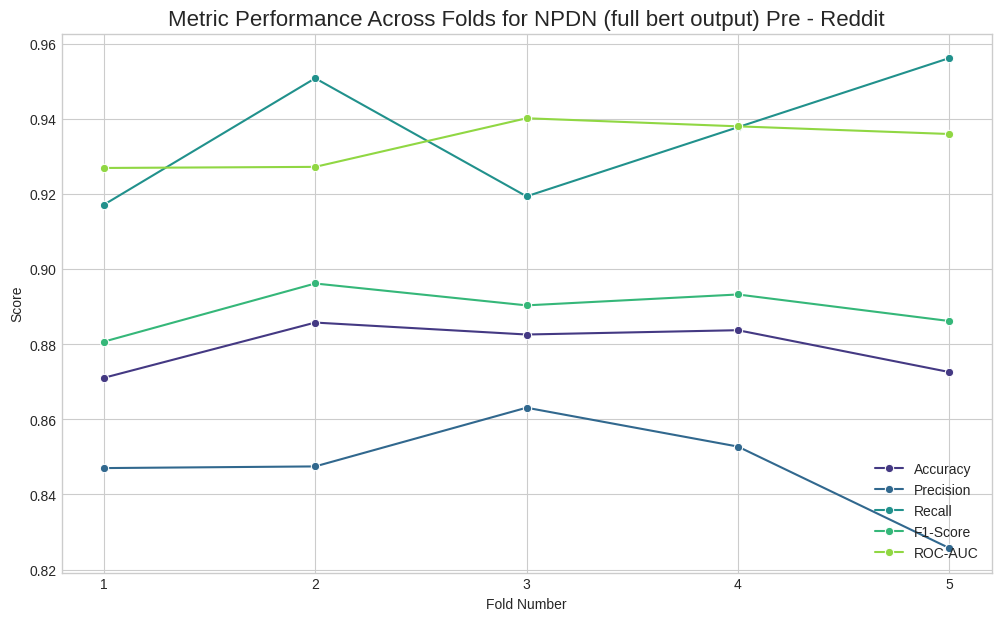

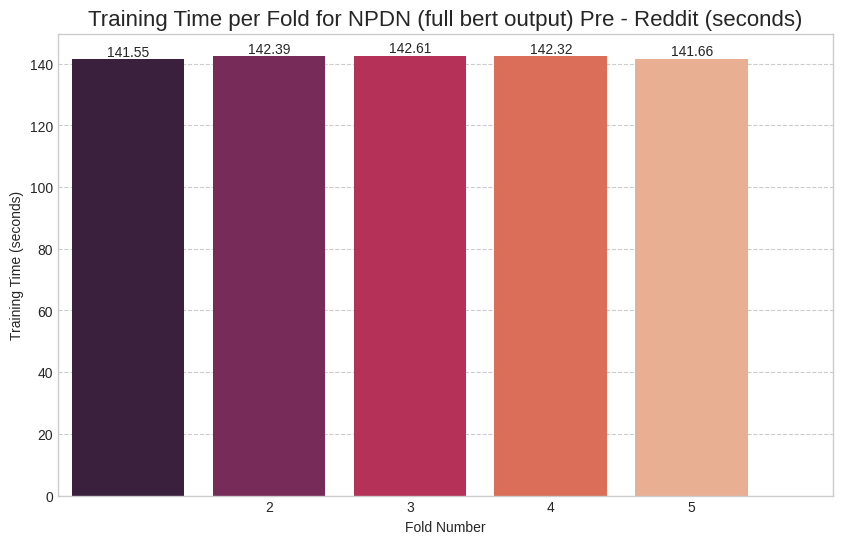

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

npdn_fb_pre_reddit_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
npdn_fb_pre_reddit_result['Variant'] = 'NPDN (full bert output) Pre'
npdn_fb_pre_reddit_result['Dataset'] = 'Reddit'
all_results.append(npdn_fb_pre_reddit_result)
analyze_cv_results(npdn_fb_pre_reddit_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/npdn_fb_pre_reddit_result.csv'
npdn_fb_pre_reddit_result.to_csv(output_filename, index=False)

del output_filename
del npdn_fb_pre_reddit_result
del X
del y
gc.collect()

In [ ]:
# New Preprocess Reddit
Reddit_path = "/content/suicidal_ideation_reddit_annotated.csv"
df_reddit = pd.read_csv(Reddit_path, encoding='latin-1')
df_reddit = df_reddit.rename(columns={'usertext': 'Text', 'label': 'Label'})
df_reddit = preprocessing_new(df_reddit)
print(df_reddit)

print(list(df_reddit['Label']).count(1), list(df_reddit['Label']).count(0))

X, y = data_preparation(df_reddit)
print(X)

del df_reddit
gc.collect()

Duplicates:
                                                   Text  Label  \
986                                                          1   
1050                                                         1   
1711                                                         1   
1805                                                         1   
2113                                                         1   
...                                                 ...    ...   
4665                                           want die      1   
5040  way call suicide hotline without trying trace ...      1   
6413  way call suicide hotline without trying trace ...      1   
5240  worried brother brother talking taking life re...      1   
6483  worried brother brother talking taking life re...      1   

                                                 Tokens  Length  
986                                                  []       0  
1050                                                 []       0

0

--- Starting Fold 1/5 ---
Model: "model_30"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

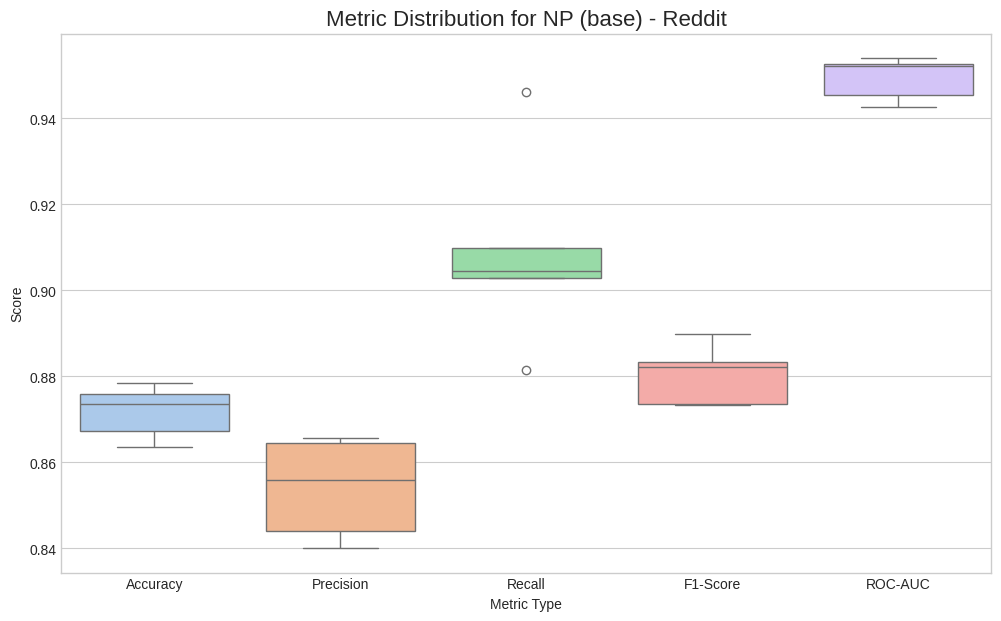

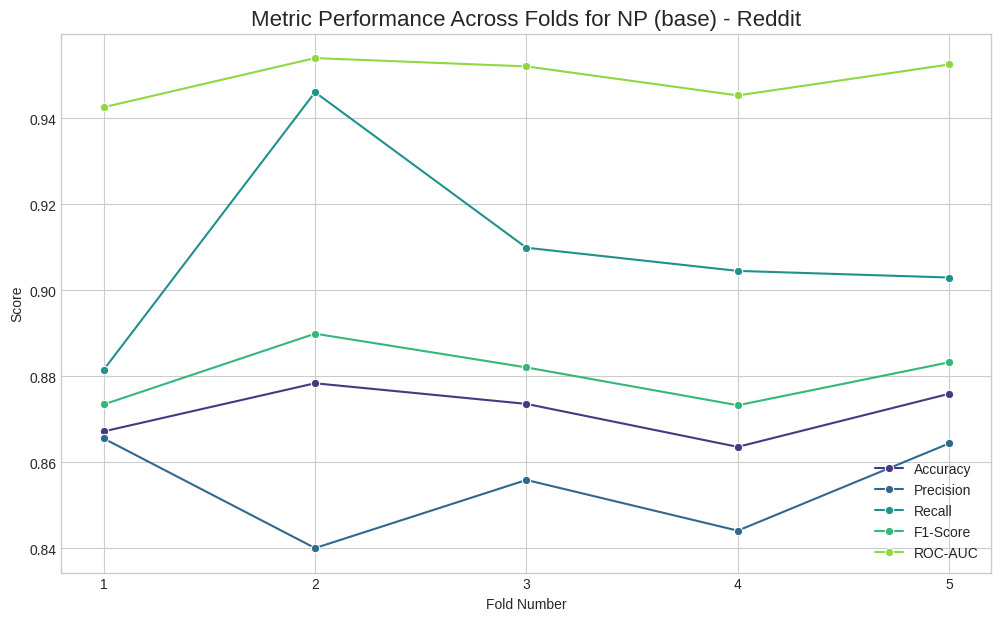

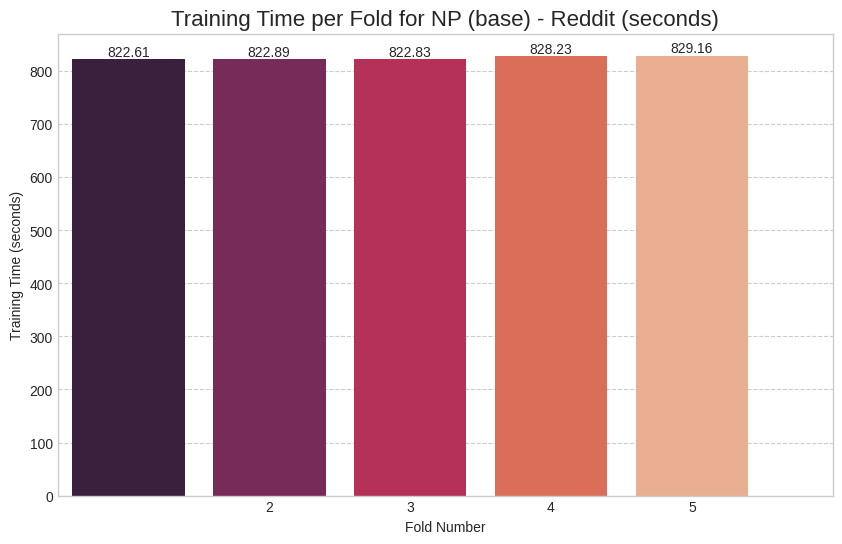

8540

In [ ]:
newp_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model)
newp_reddit_result['Variant'] = 'NP (base)'
newp_reddit_result['Dataset'] = 'Reddit'
all_results.append(newp_reddit_result)
analyze_cv_results(newp_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newp_reddit_result.csv'
newp_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newp_reddit_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_35"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

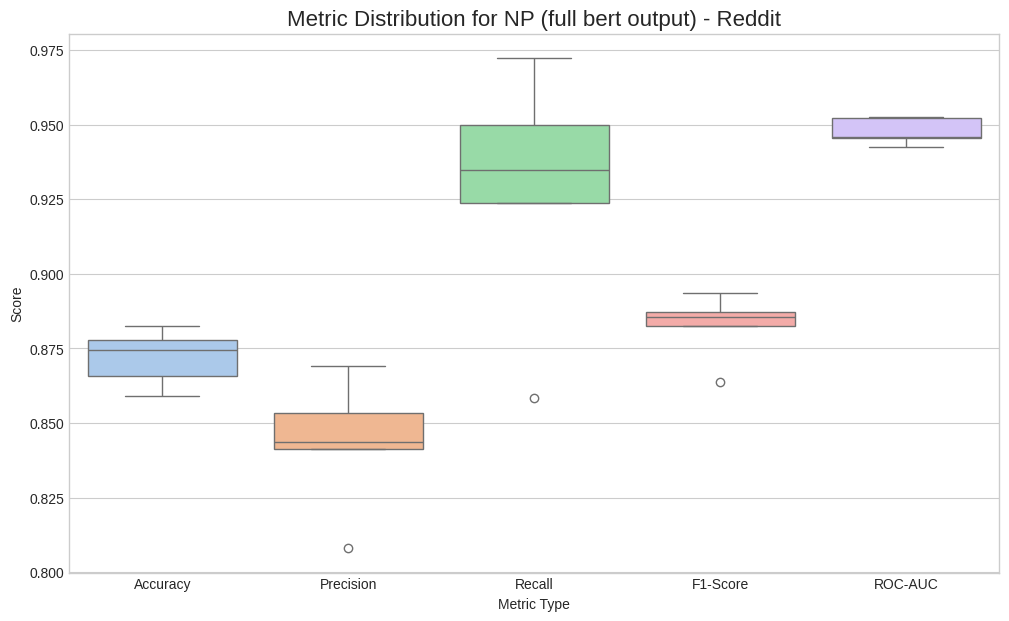

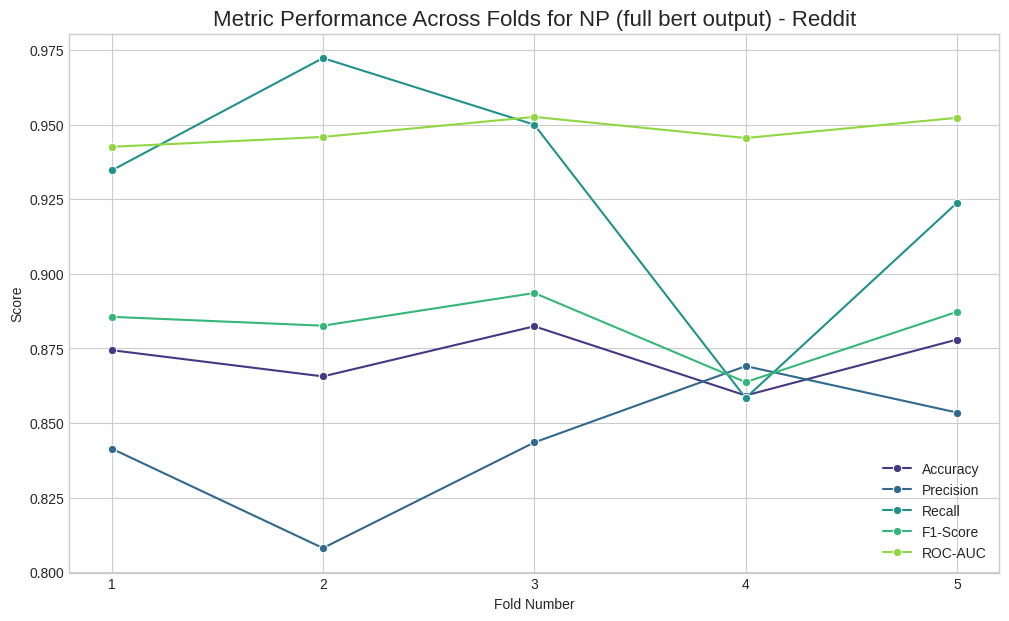

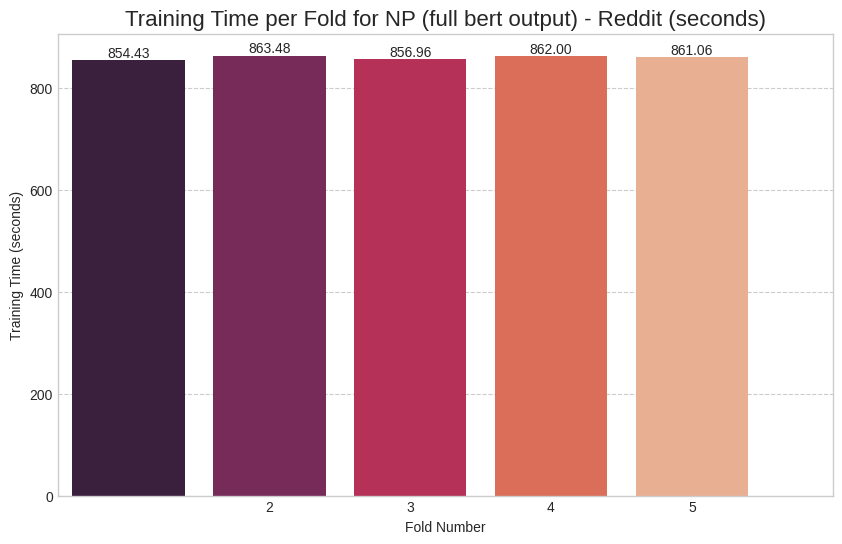

8326

In [ ]:
newp_fb_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
newp_fb_reddit_result['Variant'] = 'NP (full bert output)'
newp_fb_reddit_result['Dataset'] = 'Reddit'
all_results.append(newp_fb_reddit_result)
analyze_cv_results(newp_fb_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newp_fb_reddit_result.csv'
newp_fb_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newp_fb_reddit_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (12499, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_40"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_40 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_40 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout

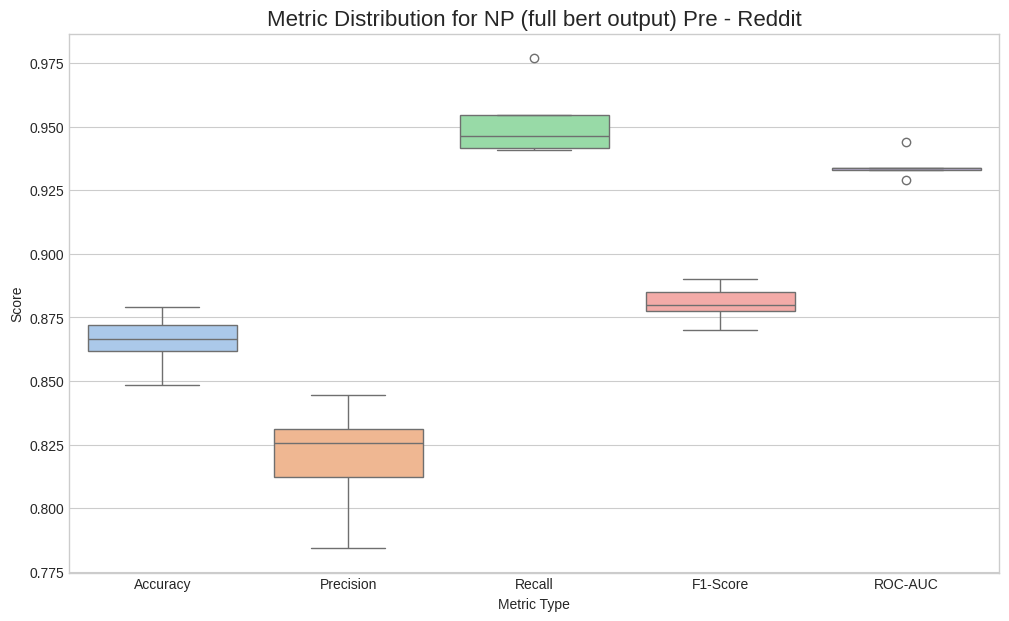

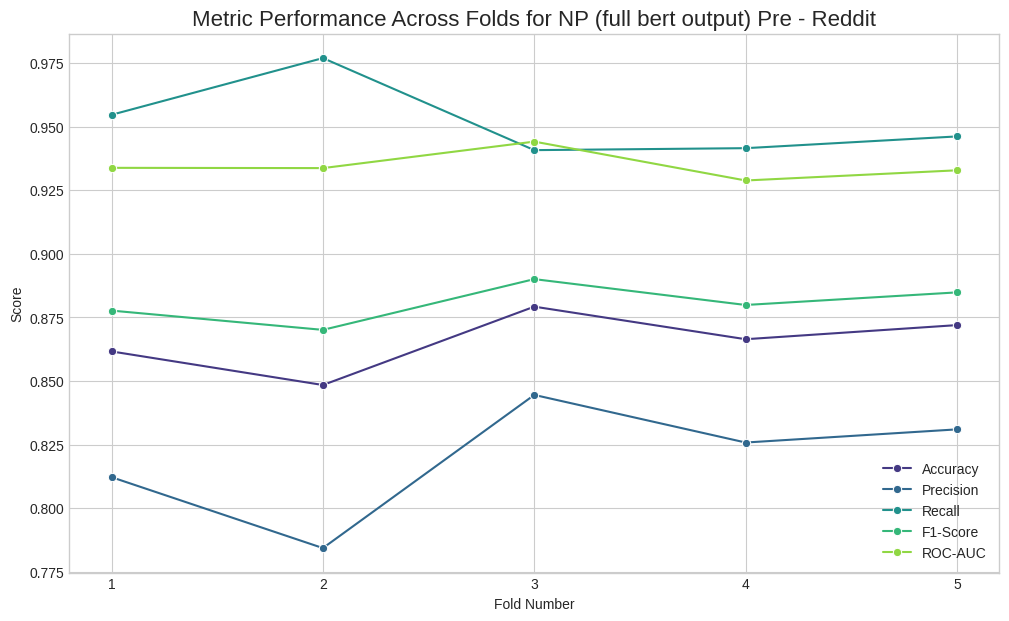

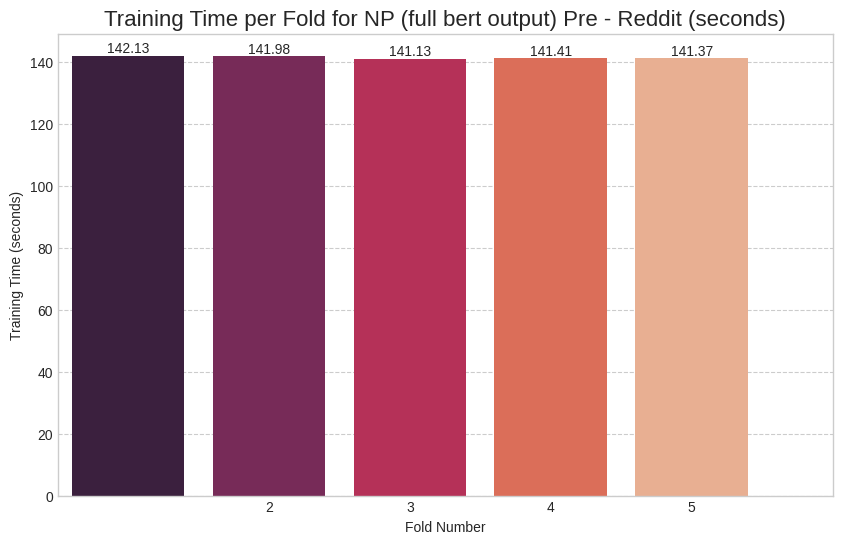

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

newp_fb_pre_reddit_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
newp_fb_pre_reddit_result['Variant'] = 'NP (full bert output) Pre'
newp_fb_pre_reddit_result['Dataset'] = 'Reddit'
all_results.append(newp_fb_pre_reddit_result)
analyze_cv_results(newp_fb_pre_reddit_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/newp_fb_pre_reddit_result.csv'
newp_fb_pre_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newp_fb_pre_reddit_result
del X
del y
gc.collect()

In [ ]:
# New Remove Stopword and NaN only (exclude dup) Reddit
Reddit_path = "/content/suicidal_ideation_reddit_annotated.csv"
df_reddit = pd.read_csv(Reddit_path, encoding='latin-1')
df_reddit = df_reddit.rename(columns={'usertext': 'Text', 'label': 'Label'})
df_reddit = preprocessing_new_rm_stop_NaN(df_reddit)
print(df_reddit)

print(list(df_reddit['Label']).count(1), list(df_reddit['Label']).count(0))

X, y = data_preparation(df_reddit)
print(X)

del df_reddit
gc.collect()

                                                    Text  Label  \
0      want end life badly life completely empty want...      1   
1      relationship complicated painful want end girl...      1   
2      owe lot money work catch barely money goes nee...      1   
3      2 october overdosed felt alone horrible hospit...      1   
4      everyone tells wonderful enough loved like lov...      1   
...                                                  ...    ...   
12651  levar burton reads podcast made realize much l...      0   
12652  irony fahrenheit 451 turned movie one noticed ...      0   
12653  anyone else ever read ben bova grand tour seri...      0   
12654  set date little longer family sorry fucking so...      0   
12655  wasted 10 000 professor going drop class show ...      0   

                                                  Tokens  Length  
0      [want, end, life, badly, life, completely, emp...      39  
1      [relationship, complicated, painful, want, end...     

0

--- Starting Fold 1/5 ---
Model: "model_45"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

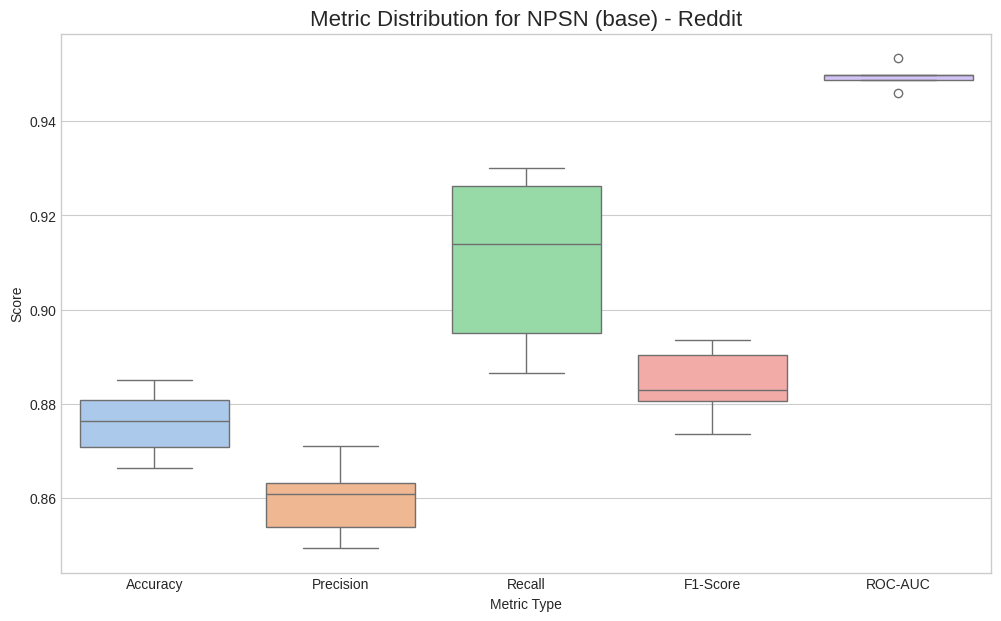

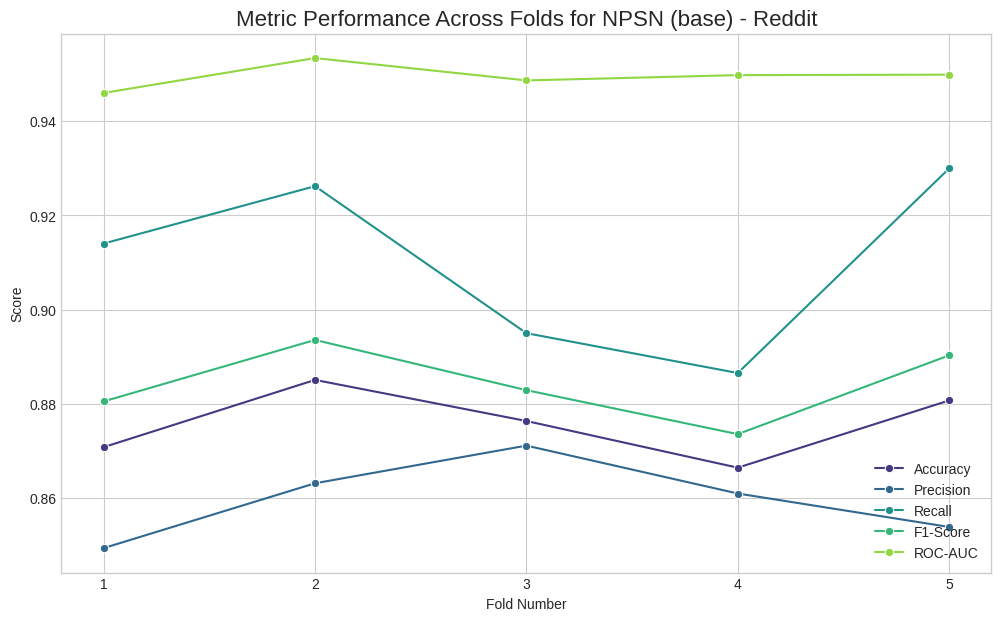

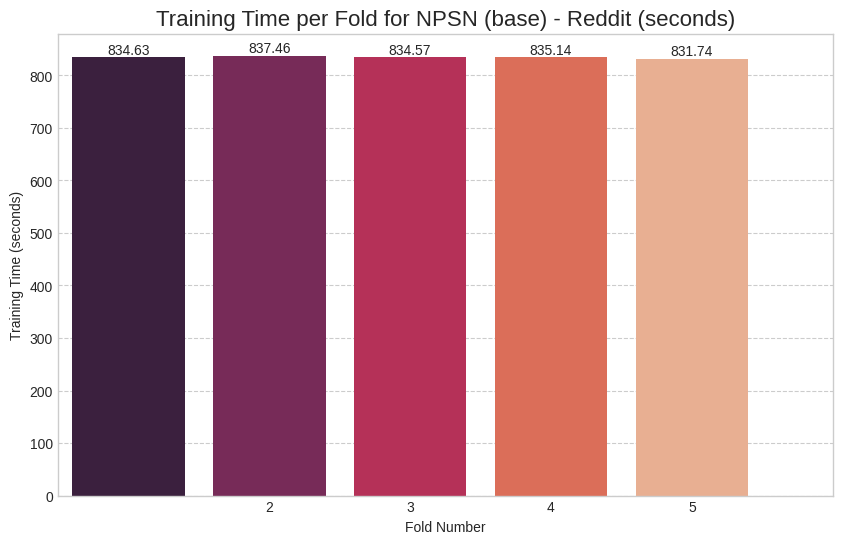

8437

In [ ]:
newpSN_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model)
newpSN_reddit_result['Variant'] = 'NPSN (base)'
newpSN_reddit_result['Dataset'] = 'Reddit'
all_results.append(newpSN_reddit_result)
analyze_cv_results(newpSN_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newpSN_reddit_result.csv'
newpSN_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newpSN_reddit_result
gc.collect()

--- Starting Fold 1/5 ---
Model: "model_50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                 

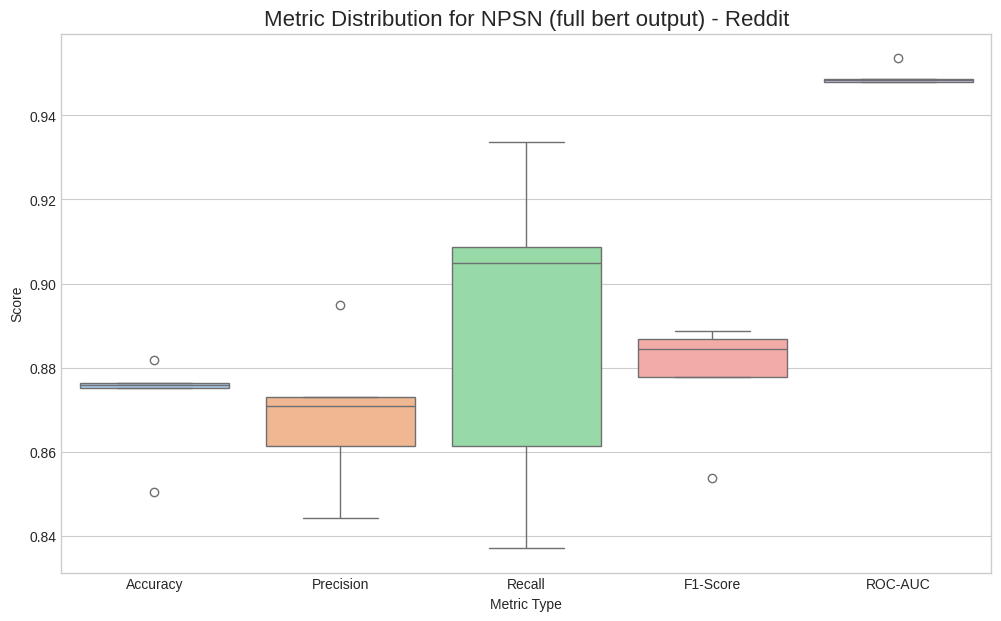

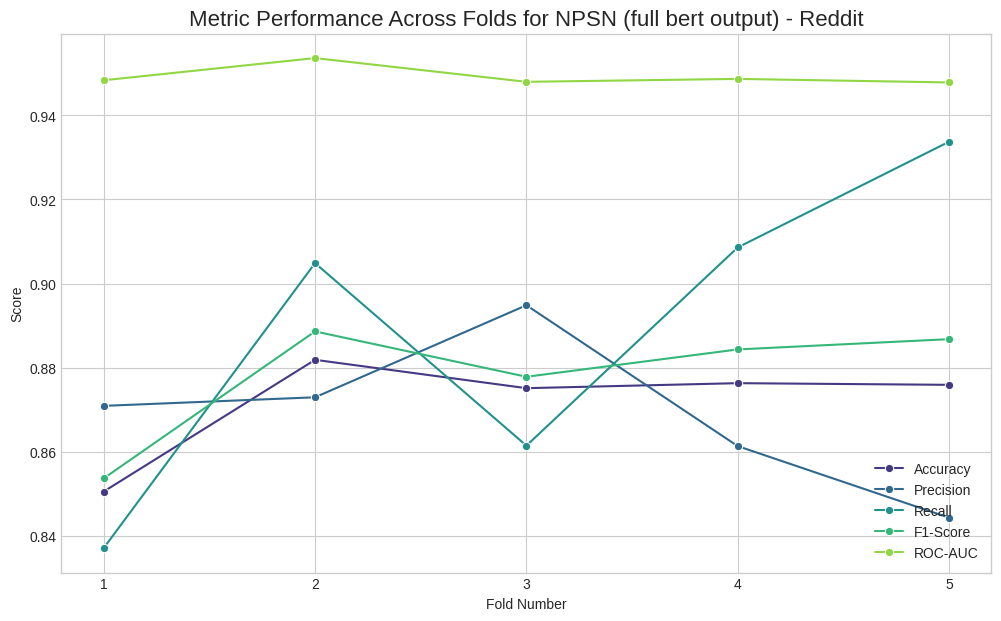

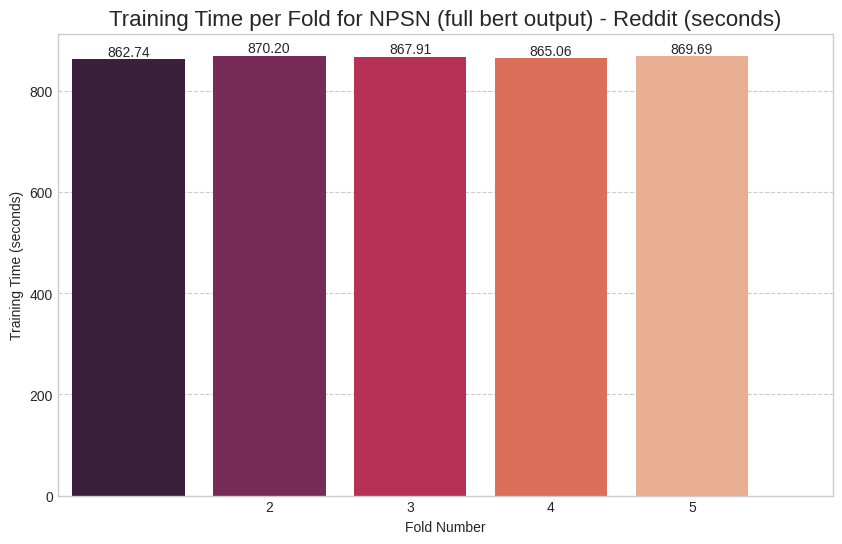

8126

In [ ]:
newpSN_fb_reddit_result = run_cross_validation(FOLDS, X, y, tcn_model_fb)
newpSN_fb_reddit_result['Variant'] = 'NPSN (full bert output)'
newpSN_fb_reddit_result['Dataset'] = 'Reddit'
all_results.append(newpSN_fb_reddit_result)
analyze_cv_results(newpSN_fb_reddit_result)

output_filename = '/content/drive/MyDrive/final_FYP_results/newpSN_fb_reddit_result.csv'
newpSN_fb_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newpSN_fb_reddit_result
gc.collect()


 Starting BERT feature extraction...
Done
Embeddings shape: (12615, 128, 512)
--- Starting Fold 1/5 ---
Model: "model_55"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 embedding_input (InputLaye  [(None, 128, 512)]           0         []                            
 r)                                                                                               
                                                                                                  
 spatial_dropout1d_55 (Spat  (None, 128, 512)             0         ['embedding_input[0][0]']     
 ialDropout1D)                                                                                    
                                                                                                  
 cu_dnnlstm_55 (CuDNNLSTM)   (None, 128, 100)             245600    ['spatial_dropout

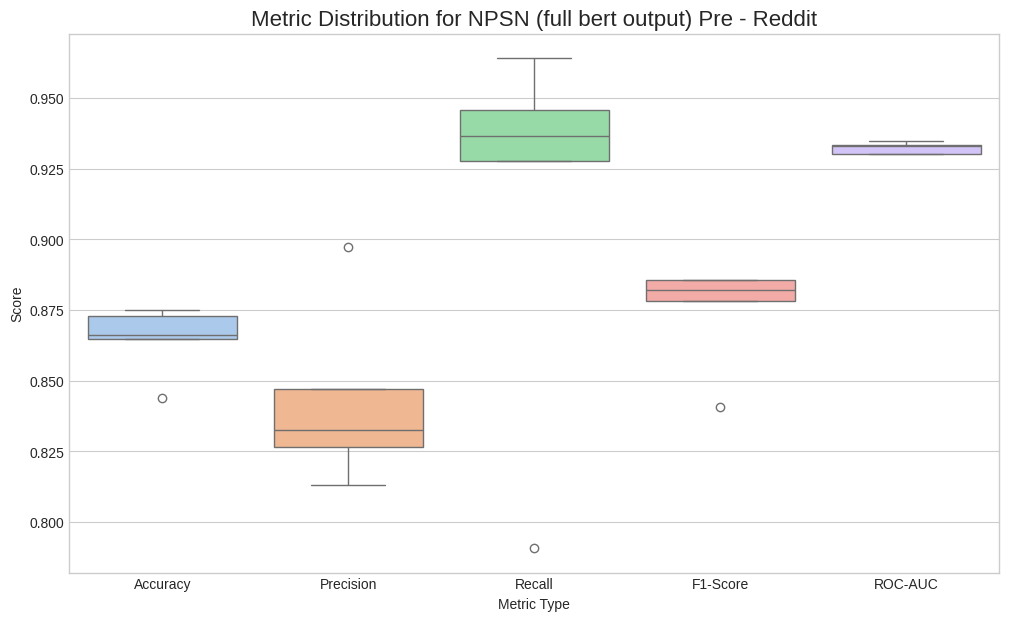

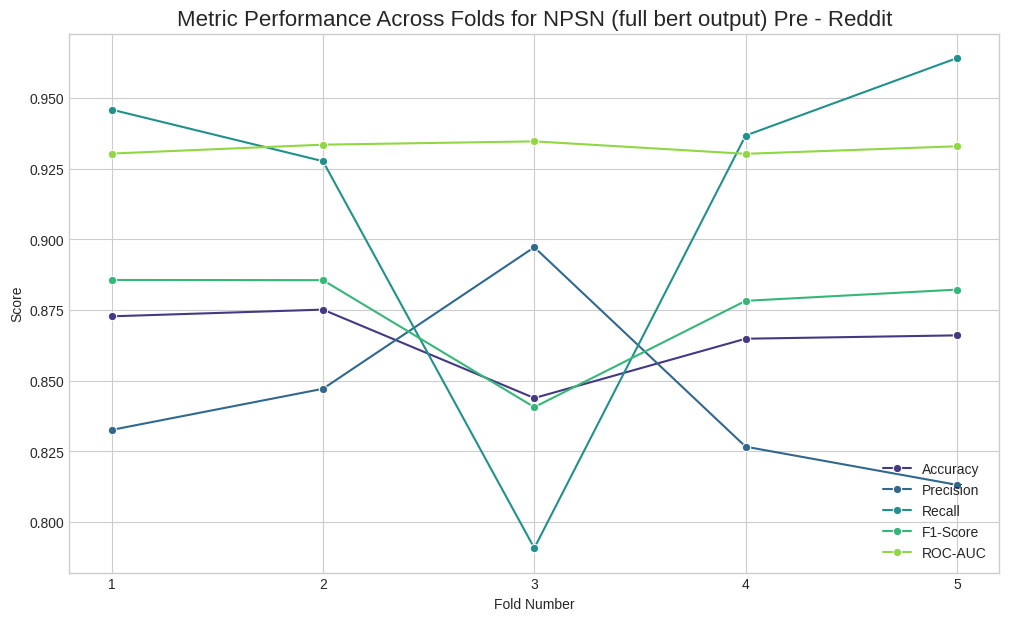

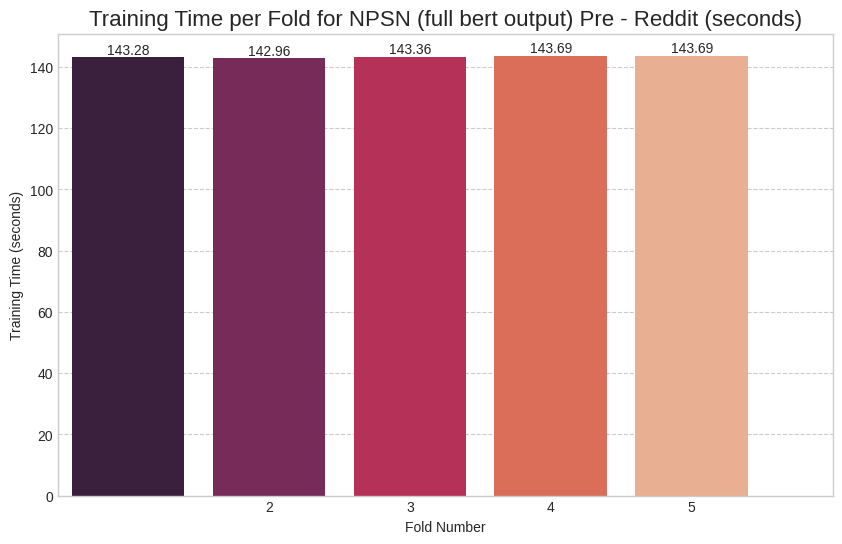

0

In [ ]:
final_embeddings = extract_feature_bert(preprocessor=preprocessor, encoder=encoder, texts=X)
print(f"Embeddings shape: {final_embeddings.shape}")

newpSN_fb_pre_reddit_result = run_cross_validation(FOLDS, final_embeddings, y, tcn_model_fb_precompute)
newpSN_fb_pre_reddit_result['Variant'] = 'NPSN (full bert output) Pre'
newpSN_fb_pre_reddit_result['Dataset'] = 'Reddit'
all_results.append(newpSN_fb_pre_reddit_result)
analyze_cv_results(newpSN_fb_pre_reddit_result)

del final_embeddings
gc.collect()

output_filename = '/content/drive/MyDrive/final_FYP_results/newpSN_fb_pre_reddit_result.csv'
newpSN_fb_pre_reddit_result.to_csv(output_filename, index=False)

del output_filename
del newpSN_fb_pre_reddit_result
del X
del y
gc.collect()

In [ ]:
def analyze_model_performance(all_results_list):
    """
    Analyzes and visualizes the performance of model variants from a list of result DataFrames.

    Args:
        all_results_list (list): A list of pandas DataFrames, each containing the results
                                 of a cross-validation run for a specific model variant.
    """
    all_results = pd.concat(all_results_list, ignore_index=True)
    print(all_results)
    # --- Summary Statistics ---
    print("--- Summary Statistics (Mean and Standard Deviation) ---")
    summary_stats = all_results.groupby(['Dataset', 'Variant']).agg({
        'Accuracy': ['mean', 'std'],
        'Precision': ['mean', 'std'],
        'Recall': ['mean', 'std'],
        'F1-Score': ['mean', 'std'],
        'ROC-AUC': ['mean','std'],
        'Training Time (s)': ['mean', 'std']
    })
    print(tabulate(summary_stats, headers='keys', tablefmt='psql'))
    print("\n" + "="*80 + "\n")

    # --- Total Training Time Statistics ---
    print("--- Total Training Time per Variant ---")
    total_time_stats = all_results.groupby(['Dataset', 'Variant'])['Training Time (s)'].sum().reset_index()
    total_time_stats = total_time_stats.rename(columns={'Training Time (s)': 'Total Training Time (s)'})
    print(tabulate(total_time_stats, headers='keys', tablefmt='psql', showindex=False))
    print("\n" + "="*80 + "\n")

    datasets = all_results['Dataset'].unique()
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)']

    for dataset in datasets:
        print(f"--- Analysis for {dataset} Dataset ---")
        dataset_results = all_results[all_results['Dataset'] == dataset]

        # --- Line Plots ---
        print(f"\n--- Line Plots for {dataset} Dataset ---")
        for metric in metrics:
            plt.figure(figsize=(15, 8))
            sns.lineplot(data=dataset_results, x='Fold', y=metric, hue='Variant', marker='o')
            plt.title(f'Line Plot of {metric} for {dataset} Dataset')
            plt.ylabel(metric)
            plt.xlabel('Fold')
            plt.grid(True)
            plt.legend(loc='lower right')
            plt.show()
            print("")

        # --- Box Plots ---
        print(f"\n--- Box Plots for {dataset} Dataset ---")
        for metric in metrics:
            plt.figure(figsize=(15, 8))
            sns.boxplot(data=dataset_results, x='Variant', y=metric)
            plt.title(f'Box Plot of {metric} for {dataset} Dataset')
            plt.ylabel(metric)
            plt.xlabel('Variant')
            plt.xticks(rotation=15)
            plt.grid(True)
            plt.show()
            print("")

        print("\n" + "="*80 + "\n")

    # --- Overall Bar Charts for Training Time ---
    print(f"\n--- Overall Bar Charts for Training Time Comparison ---")

    # --- Bar Chart for Mean Training Time ---
    mean_time_stats = summary_stats['Training Time (s)']['mean'].reset_index()
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(data=mean_time_stats, x='Variant', y='mean', hue='Dataset', dodge=True)
    for container in ax.containers:
      ax.bar_label(container, fmt='%.2f')
    plt.title('Mean Training Time per Fold (Reddit Datasets)')
    plt.ylabel('Mean Training Time (s)')
    plt.xlabel('Variant')
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.show()
    print("")

    # --- Bar Chart for Total Training Time ---
    plt.figure(figsize=(18, 10))
    ax = sns.barplot(data=total_time_stats, x='Variant', y='Total Training Time (s)', hue='Dataset', dodge=True)
    for container in ax.containers:
      ax.bar_label(container, fmt='%.2f')
    plt.title('Total Training Time (Reddit Datasets)')
    plt.ylabel('Total Training Time (s)')
    plt.xlabel('Variant')
    plt.xticks(rotation=25, ha='right')
    plt.grid(axis='y', linestyle='--')
    plt.show()

    return summary_stats

    Fold  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0      1  0.871248   0.898400  0.849470  0.873250  0.958143   
1      2  0.874358   0.870753  0.891831  0.881166  0.952202   
2      3  0.873568   0.889580  0.865356  0.877301  0.955469   
3      4  0.885421   0.880531  0.903177  0.891710  0.956168   
4      5  0.884235   0.864539  0.922786  0.892713  0.953970   
5      1  0.874803   0.902967  0.851740  0.876606  0.956672   
6      2  0.881470   0.866046  0.914523  0.889625  0.952955   
7      3  0.892928   0.874555  0.928139  0.900550  0.954008   
8      4  0.891742   0.892216  0.901664  0.896915  0.957623   
9      5  0.873568   0.868286  0.893263  0.880597  0.946163   
10     1  0.890600   0.866667  0.934191  0.899163  0.944850   
11     2  0.875938   0.849030  0.927383  0.886479  0.935207   
12     3  0.872778   0.867647  0.892587  0.879940  0.932544   
13     4  0.881075   0.867531  0.911498  0.888971  0.935219   
14     5  0.887791   0.859321  0.938683  0.897250  0.93

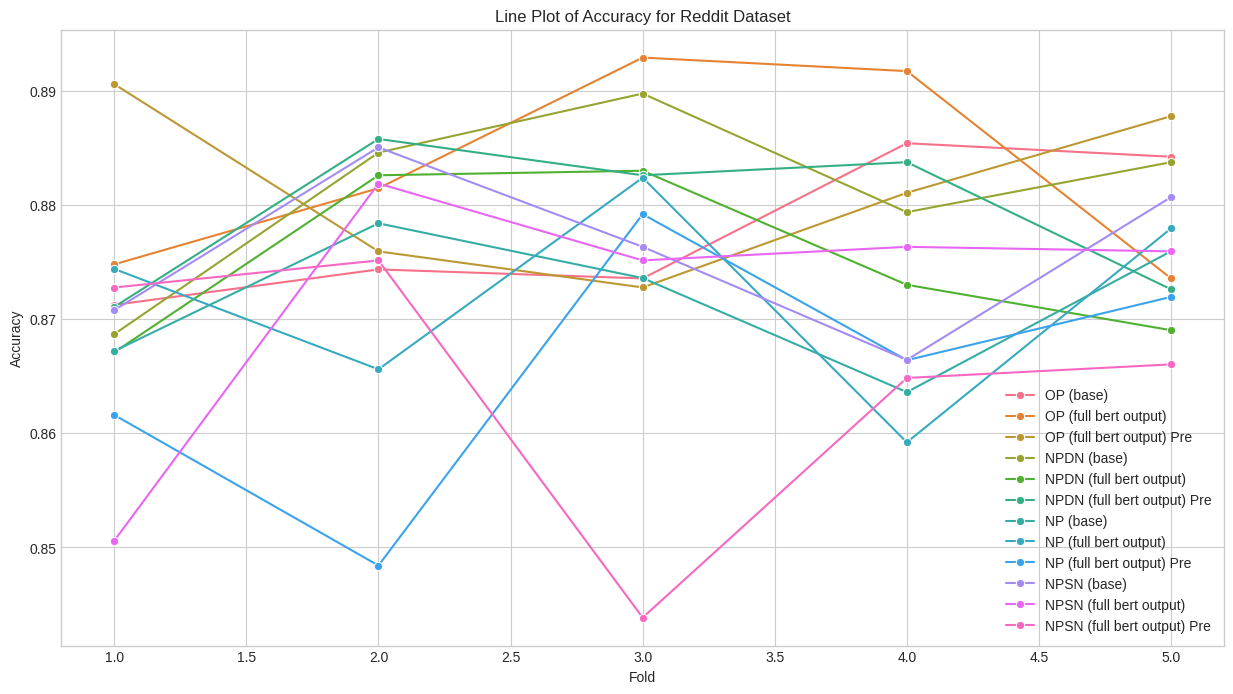

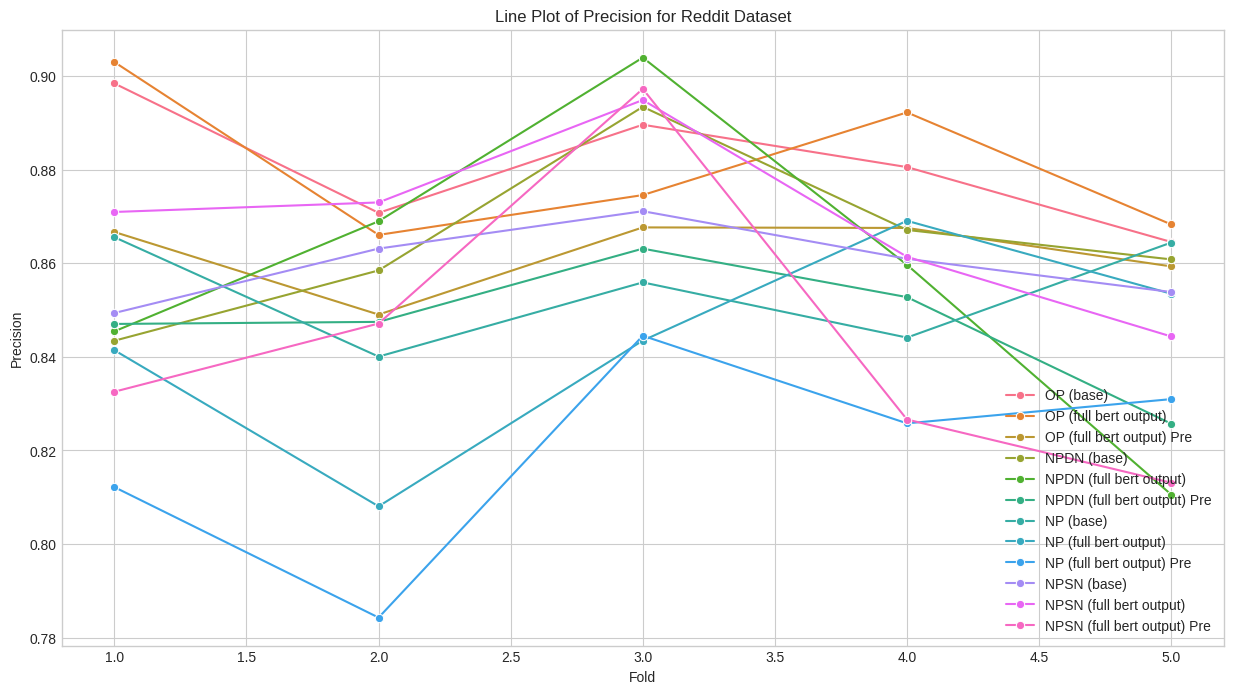

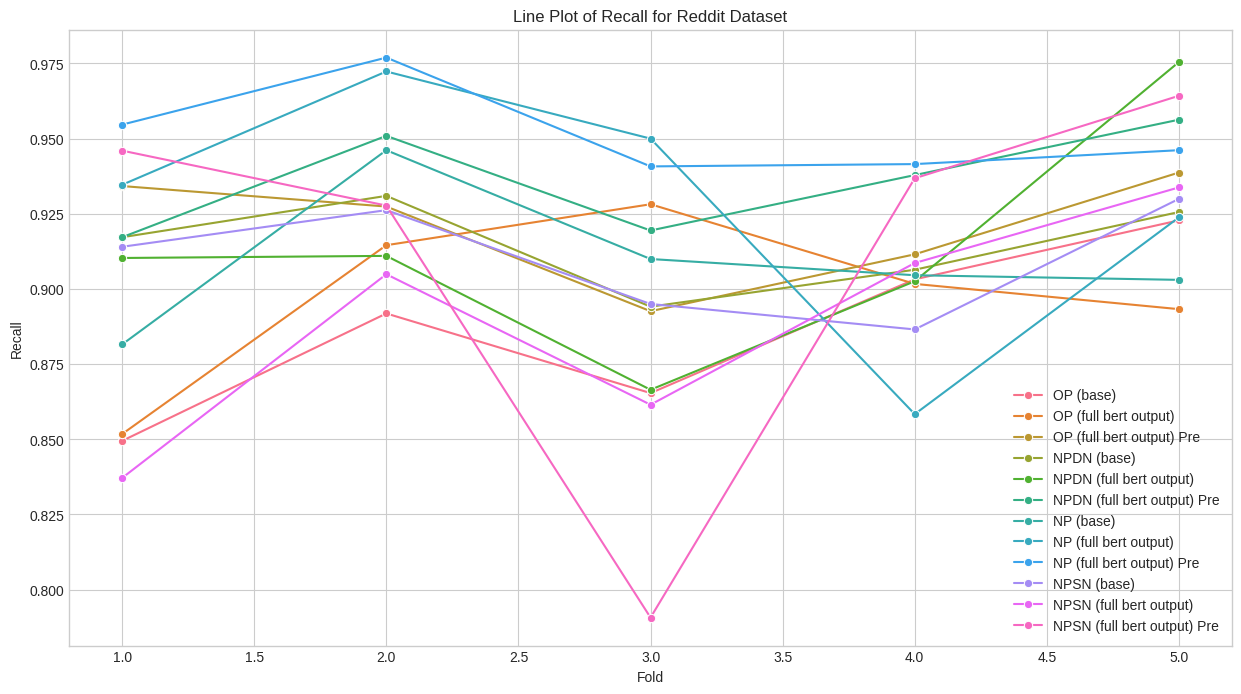

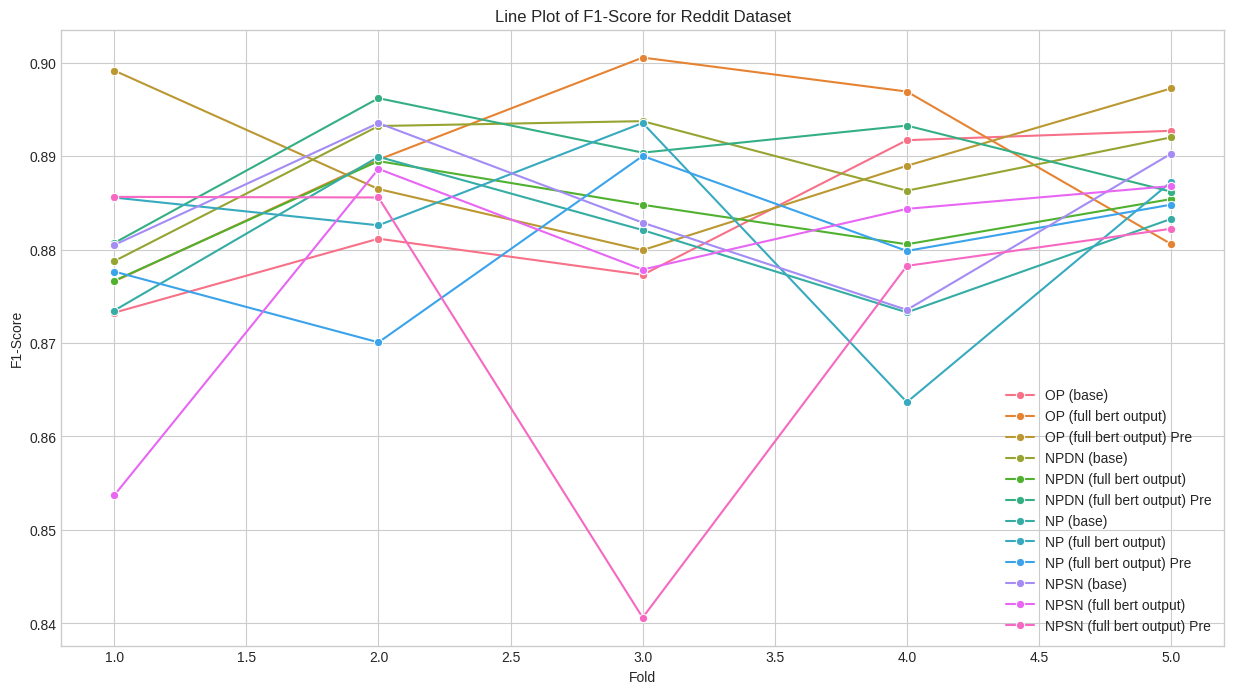

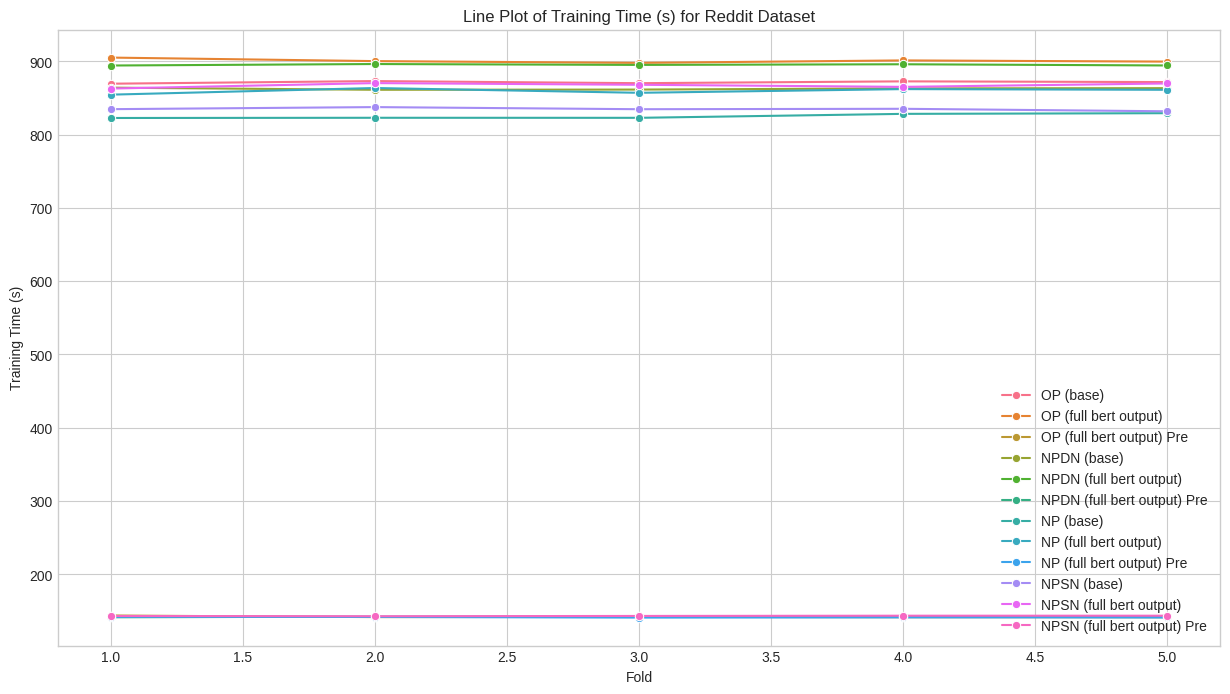



--- Box Plots for Reddit Dataset ---


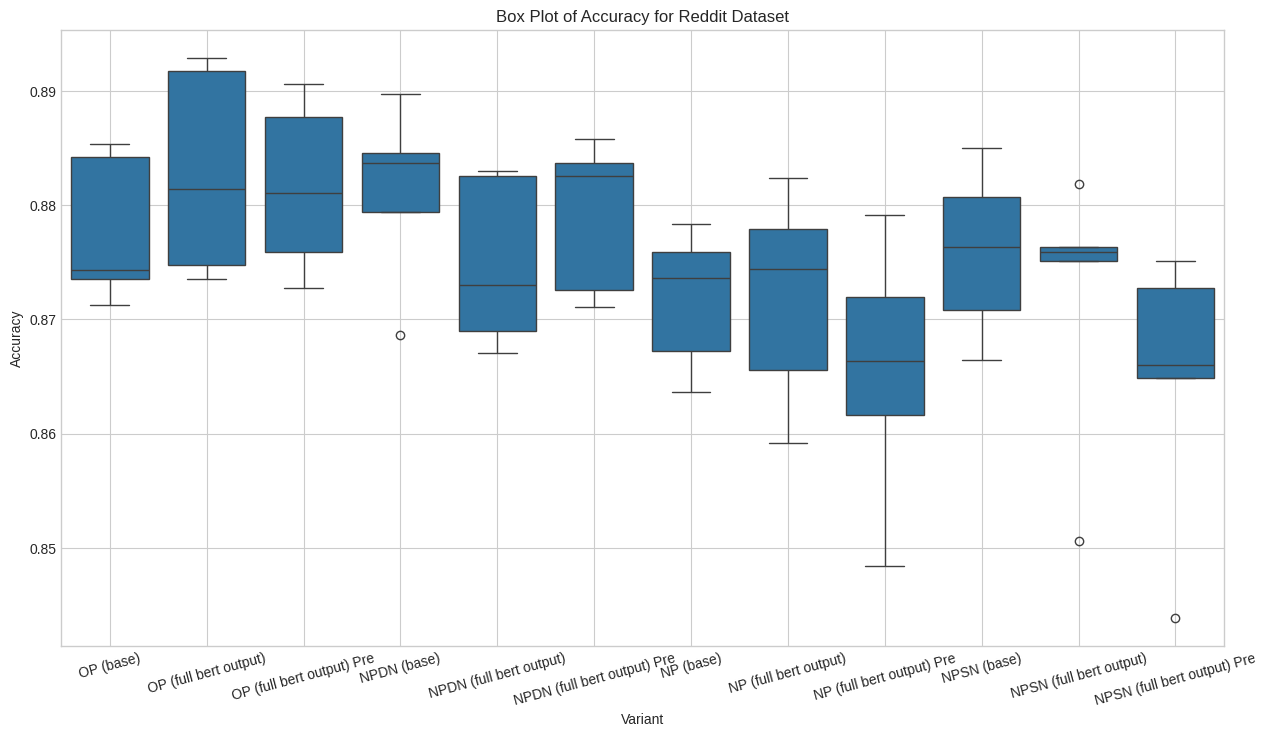

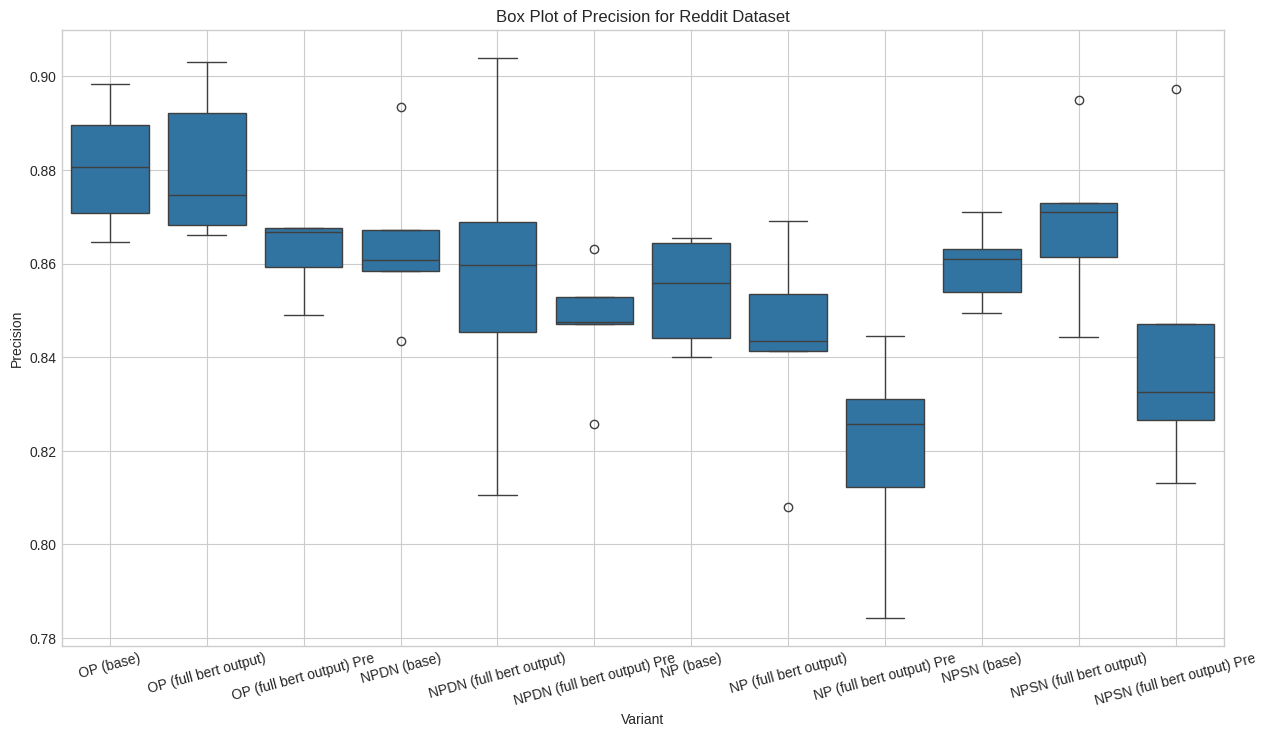

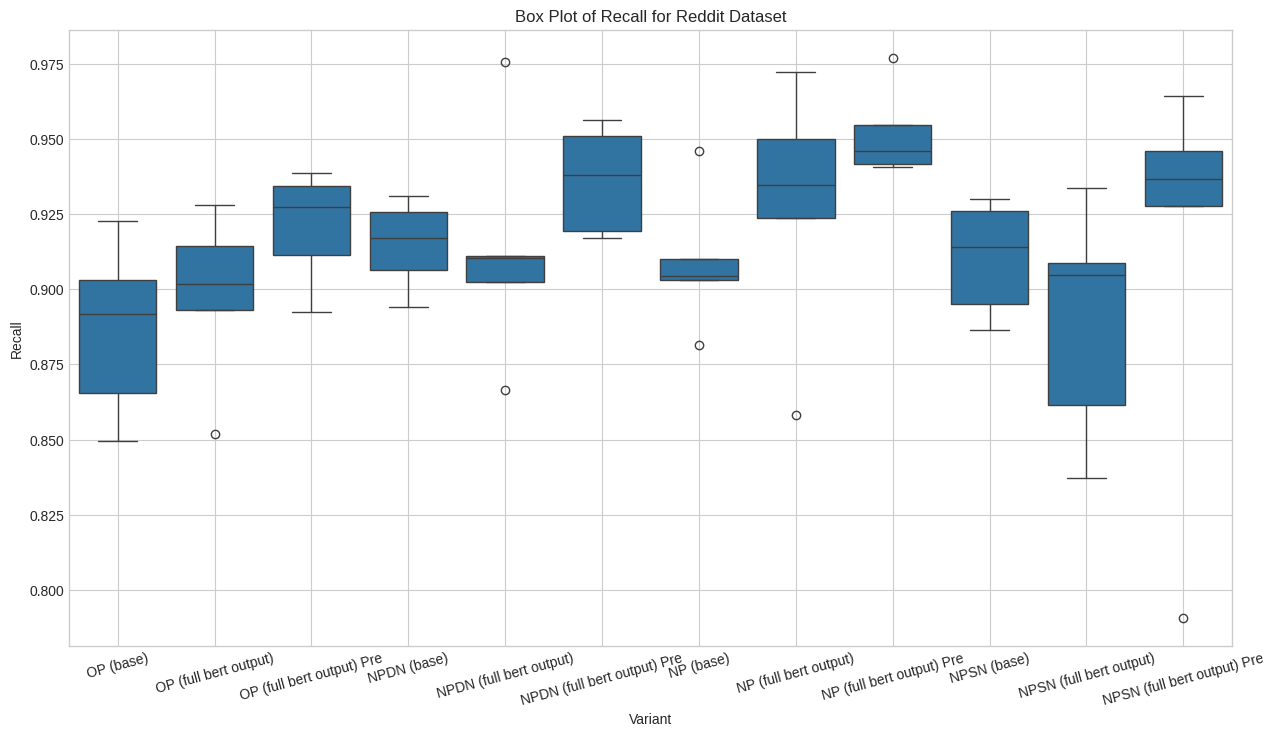

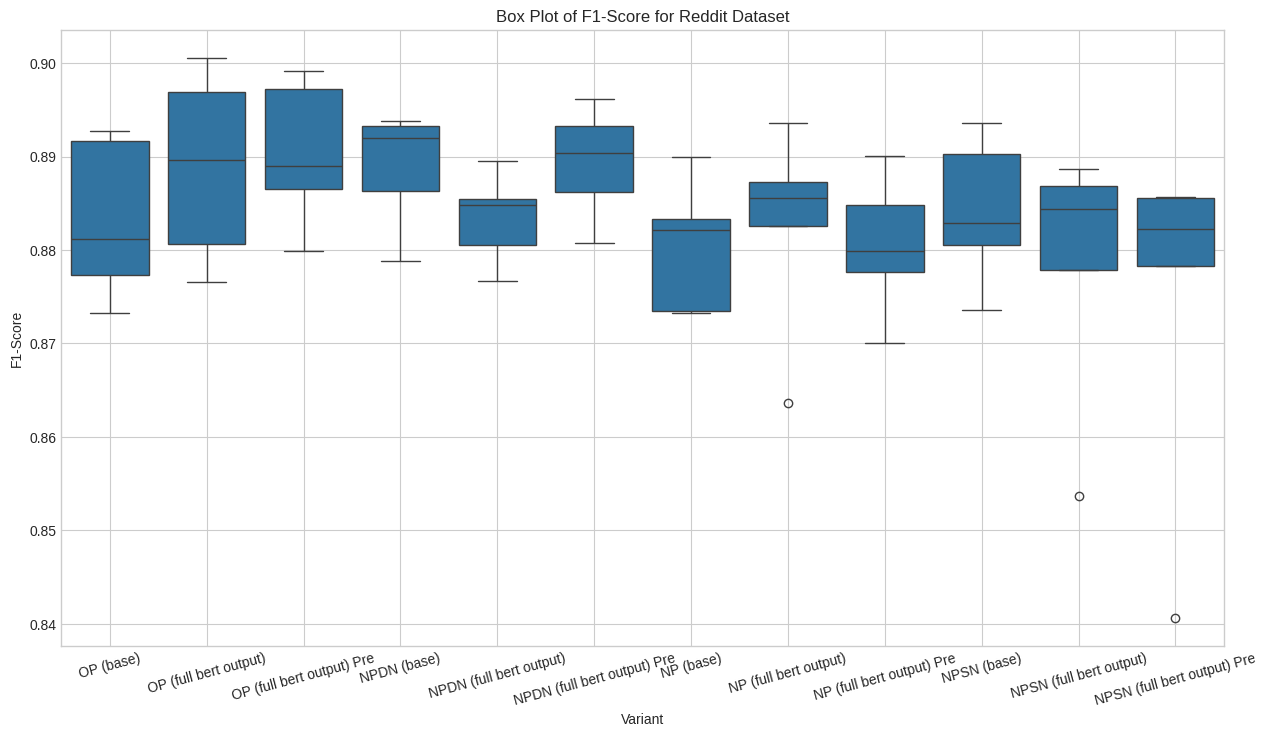

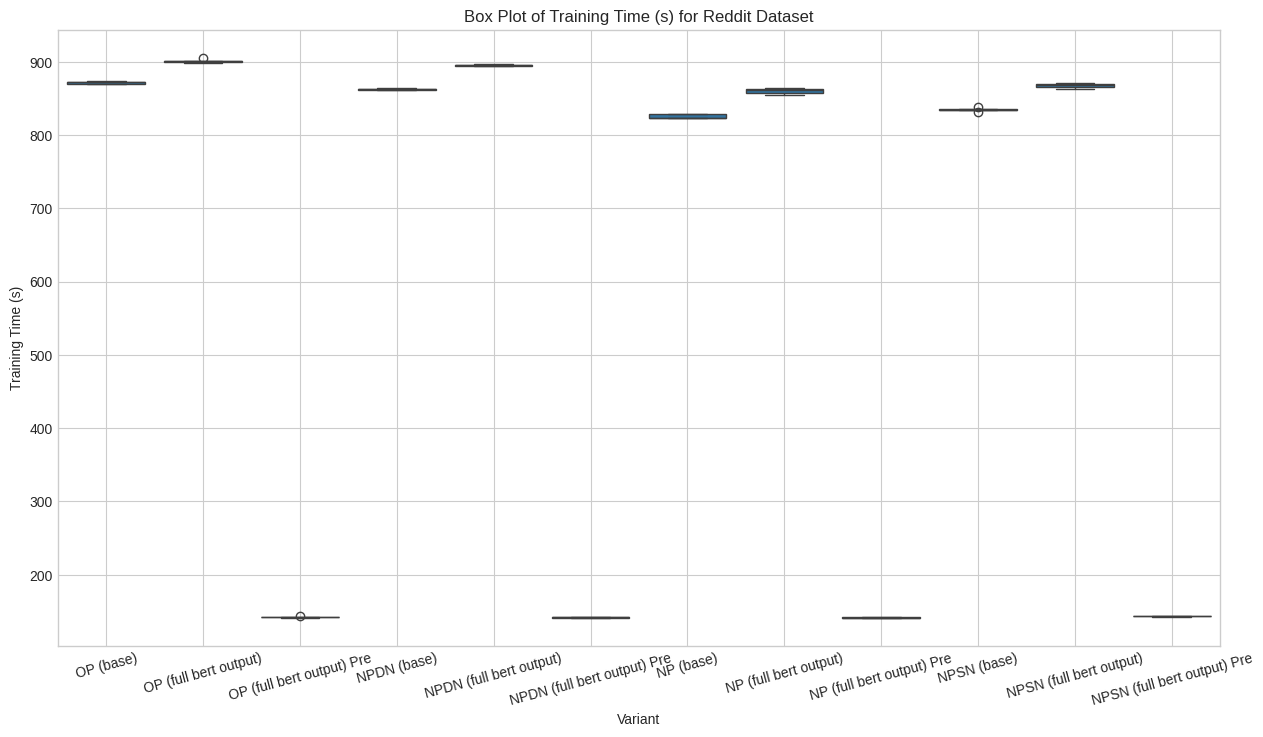





--- Overall Bar Charts for Training Time Comparison ---


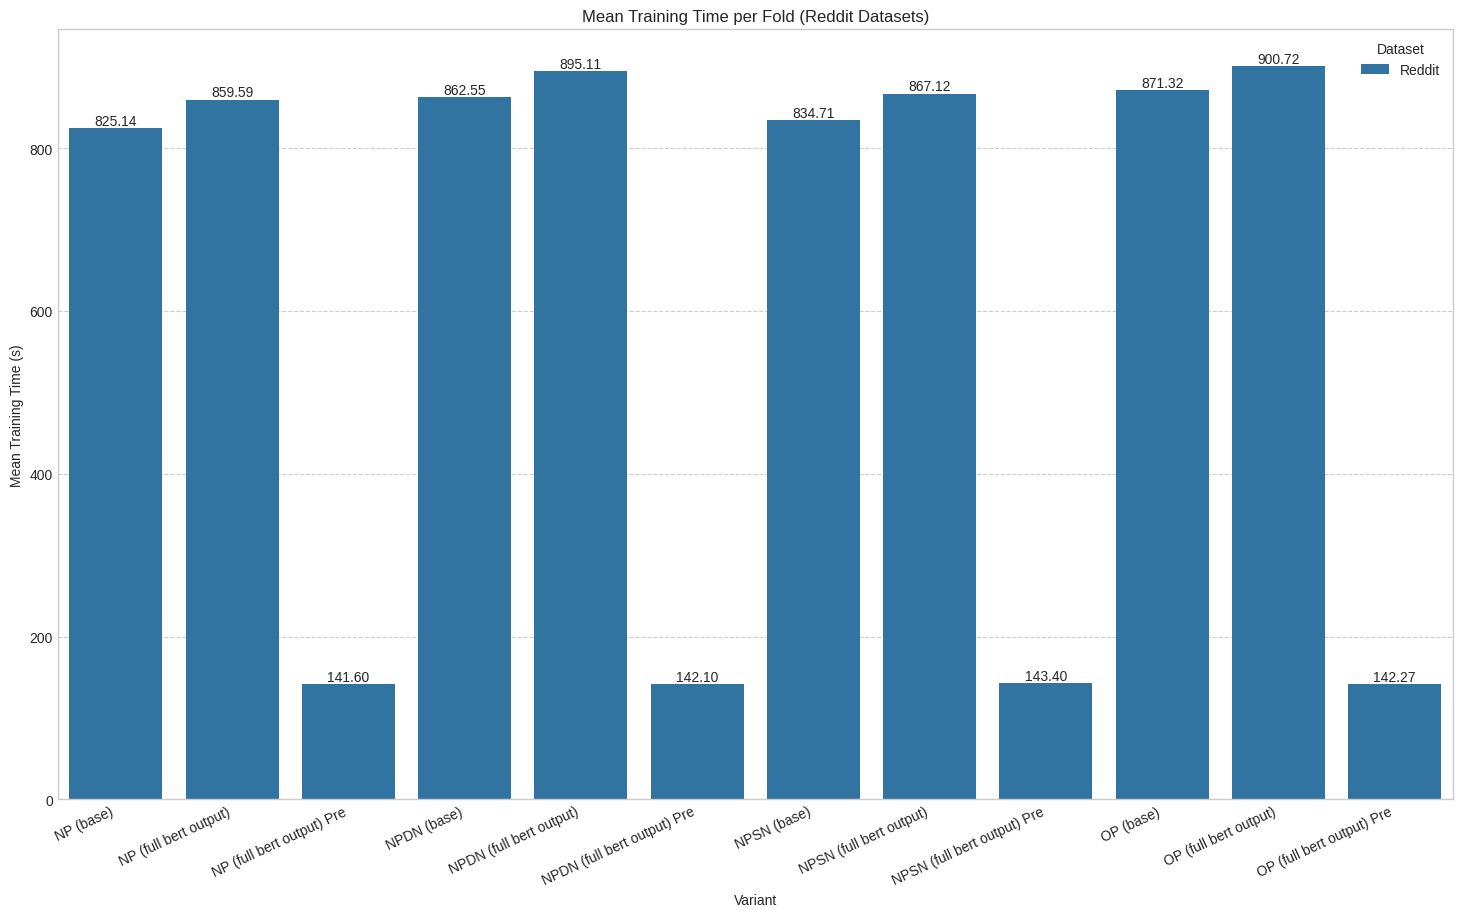

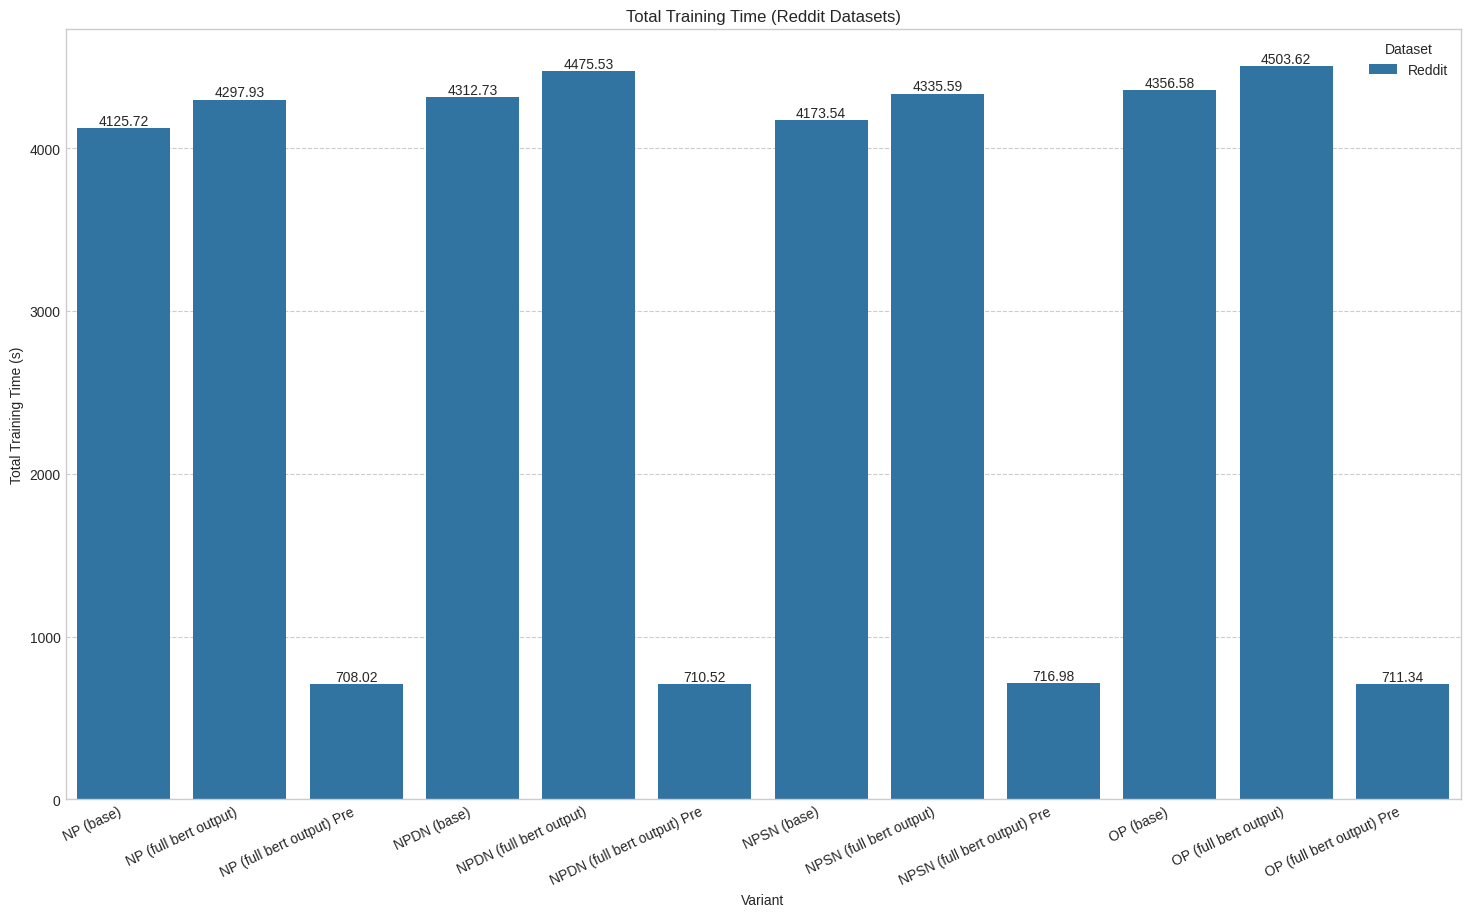

In [ ]:
summary_stats = analyze_model_performance(all_results)

output_filename = '/content/drive/MyDrive/final_FYP_results/reddit_results_preprocess.csv'
all_results_pd = pd.concat(all_results, ignore_index=True)
all_results_pd.to_csv(output_filename, index=False)
summary_stats.to_csv('/content/drive/MyDrive/final_FYP_results/reddit_summary_stats_preprocess.csv')